In [1]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 

from collections import Counter
import copy, sys, os
import matplotlib.pyplot as plt
from tqdm import tqdm 
# adding path to folder

from utils_analysis import ParticleCode, load_dataset, load_util_dataset
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

sys.path.insert(0, '../tools/')
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match

In [2]:
# Load datasets 
n_files = 1023
location = "nersc"
type="mr6.2"
df = load_dataset(n_files,location, type)
# Create a caf reader
caf_reader = CafReader(df)
pdg_tab = ParticleCode()


Reading  1023  files gk
Location selected nersc
Openning MiniRun 6.2 CAFs


  0%|          | 0/1023 [00:00<?, ?it/s]

100%|██████████| 1023/1023 [45:25<00:00,  2.66s/it]


In [82]:
# #first lets look for reco interactions that produced more than one proton

tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163

# ----------- NEUTRINO SELECTION FUNCTIONS ------------------------------------
# -----------------------------------------------------------------------------


# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal

# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,proton_threshold=2,QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            #(ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )

        # Need to add a way to check protons below 40 MeV 
        for ix in range(ev_data['rec.mc.nu..length']):
            if mask_t[ix]: 
                n_particles = ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                    if pdg == pdg_tab.proton: 
                        xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                        ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                        zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                        xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                        ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                        ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                        track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                        if track_length < proton_threshold:
                            continue
                        else: signal[ix] = False
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=True):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv, True)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

# Step 2.5 select tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out


def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv, exclusive=True):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count_prim = 0
        count_sec = 0 

        if(exclusive):
            for ip in range(n_pre,n_pre+n_vtx):
                count_prim += ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                count_sec += 1 if not ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0 
        
            if count_prim == 1 and count_sec==1:
                continue
            else:
                QE_signal[vtx] = 0
        else:
            for ip in range(n_pre, n_pre+n_vtx):
                count_prim +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                if count_prim > 1: break 
            if count_prim != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal, reco_vertices_signal):

    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_ixn = None
    # max_overlap = 0
    # best_match_idx = 0
    # best_match_ixn = 0 
    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_ixn = temp_tp_ixn

    if best_match_ixn is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_ixn] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            reco_vertices_signal[vtx_index] = True
            return True, best_match_ixn, reco_vertices_signal
    return False, best_match_ixn, reco_vertices_signal

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Scattering Mode of Vertices Matching Signal')
    plt.axis('equal')
    plt.show()


def display_summary(efficiency, purity, scattering_counters, current_counters, insignal_counters):
# Print and plot results    
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")
    
def get_trk_length(start_point,end_point):
    dx = start_point[0][:] - end_point[0][:]
    dy = start_point[1][:] - end_point[1][:]
    dz = start_point[2][:] - end_point[2][:]
    trk_length = np.sqrt( np.square(dx) + np.square(dy) + np.square(dz))
    return trk_length


# ------------------------- NEUTRON SELECTION FUNCTIONS ----------------------
# ----------------------------------------------------------------------------

def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def around_vtx_region(part_pos, vtx_pos, radius):
    """Check if a particle position is outside a 
    spherical exclusion region around the vertex."""
    distance = np.linalg.norm(np.array(part_pos) - np.array(vtx_pos))
    return distance > radius

def around_track_region(point, xs, xe, radius):
    """Check if a point is outside a cylinder with a 
    given radius around muon track."""
    point = np.array(point)
    xs = np.array(xs)
    xe = np.array(xe)
    line_vec = xe - xs
    point_vec = point - xs
    line_length = np.linalg.norm(line_vec)

    if line_length == 0:
        raise ValueError("Track length should not be zero.")
    else:
        line_unit_vec = line_vec / line_length
        projection_length = np.dot(point_vec, line_unit_vec)
        projection_length = np.clip(projection_length, 0, line_length)
        closest_point = xs + projection_length * line_unit_vec
        distance_to_line = np.linalg.norm(point - closest_point)
    
    return distance_to_line > radius


def muon_track_info(reco_info, true_info):
    #primary muon track of the interaction
    muon_track_mask = (
                (reco_info['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
                (reco_info['rec.common.ixn.dlp.part.dlp.pdg']== pdg_tab.muon)
    )
    muon_sx = reco_info['rec.common.ixn.dlp.part.dlp.start.x'][muon_track_mask]
    muon_sy = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_sz = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_ex = reco_info['rec.common.ixn.dlp.part.dlp.end.x'][muon_track_mask]
    muon_ey = reco_info['rec.common.ixn.dlp.part.dlp.end.y'][muon_track_mask]
    muon_ez = reco_info['rec.common.ixn.dlp.part.dlp.end.z'][muon_track_mask]        
    start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    return start_point, end_point

def part_scanner(ev_data,reco_data, vtx, r_sph=0,r_cil=0, verbose=True):
    track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None, None
    #if (verbose): print(f'Selecting particles {r_sph} cm away vertex and {r_cil} cm around muon track')
    #muon_track_start, muon_track_end  = muon_track_info(reco_data, true_data)
    n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])

    #store the reco particles of the current vertex vtx
    reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[]}

    for ip in range(n_part):
        vtx_pos = [
                reco_data['rec.common.ixn.dlp.vtx.x'],
                reco_data['rec.common.ixn.dlp.vtx.y'], 
                reco_data['rec.common.ixn.dlp.vtx.z']
            ]
        ip_start = [
            reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ]
        ip_end = [
            reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ]
        # Check if the particle is in ROI
        #in_FV = isContainedFV(ip_start)
        #outside_vtx = around_vtx_region(ip_start, vtx_pos, r_sph)
        #outside_track = around_track_region(ip_start, muon_track_start, muon_track_end, r_cil)
        
        #if outside_vtx and in_FV: #and outside_track and in_FV:
        ip_pdg = reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
        is_primary = reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
        
        # if secondary proton, find the match
        if (ip_pdg==pdg_tab.proton) and (is_primary==False): 
        #if (is_primary==False): 
            best_match_type, best_match_ixn, best_match_idx, parent_id= match_finder(ev_data, reco_data, vtx,ip)          
            track_length, vtx_distance = calculate_track_properties(ip_start, ip_end, vtx_pos)
            if best_match_type is not None:
                reco_dic['best_match_type'].append(best_match_type)
                reco_dic['best_match_ixn'].append(best_match_ixn)
                reco_dic['best_match_idx'].append(best_match_idx)
                reco_dic['parent_id'].append(parent_id)
                reco_dic['length'].append(track_length)
                reco_dic['distance'].append(vtx_distance)
                reco_dic['energy'].append(reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])

            #else: continue
    return reco_dic


def match_finder(ev_data, reco_data, vtx, ip):
    best_match_type = None
    best_match_ixn=None
    best_match_idx=None
    parent_id=None

    max_overlap=0
    n_part= ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
    print('n_pre',n_pre)
    idx_ev= [n_pre, n_pre+n_part]
    print('index in ev:',idx_ev)
    idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
    print('actual range' , idx_ev_data)
    n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    ip_ev = idx_ev_data[ip]
    print('index of ip in ev',ip_ev)
    print(f'particle {ip} out of {n_part} has {n_overlaps} overals and it is at {ip_ev} index')
    if ip_ev ==0 : truth_pre = 0
    else: truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
    print('range:',truth_pre,truth_pre+n_overlaps)
    overlaps=ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
    print(overlaps)
    matches = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
    print(matches)
    types = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
    #print(types)
    ixns = ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
    #print(ixns)
    for tp in range(n_overlaps):
        print('First overlap:', tp)
        temp_overlap=overlaps[tp]
        temp_tp_match=matches[tp]
        temp_tp_type=types[tp]
        temp_tp_ixn=ixns[tp]
        if(temp_overlap>max_overlap):
            max_overlap=temp_overlap
            best_match_idx=temp_tp_match
            best_match_type=temp_tp_type
            best_match_ixn=temp_tp_ixn

    if(best_match_type==3):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nsec'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nsec'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        parent_id = ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match seconday {best_match_pdg}\n ')
    if(best_match_type==1):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nprim'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nprim'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match primary {best_match_pdg}\n ')


    return best_match_type, best_match_ixn, best_match_idx, parent_id



def get_bm_truth_data(bm_truth_data,bm_type, bm_idx):
    bm_dic={'type': bm_type}

    if bm_type ==1: 
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(
            (  
                bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        
        # bm_dic['length'] = track_length_truth
        # bm_dic['distance'] = vtx_distance_truth
        
    elif(bm_type==3):
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
        bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(

            (  
                bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        # bm_dic['length'] = track_length_truth
        # bm_dic['distance'] = vtx_distance_truth

    return bm_dic


# TRUE NEUTRINO MULTIPLICITY HERE

def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

n_pre 1
index in ev: [1, 8]
actual range [1, 2, 3, 4, 5, 6, 7]
index of ip in ev 3
particle 2 out of 7 has 2 overals and it is at 3 index
range: 4 6
[0.9166667 0.04     ]
[5 4]
First overlap: 0
First overlap: 1
particle 2 has best match primary 2212
 
n_pre 1
index in ev: [1, 8]
actual range [1, 2, 3, 4, 5, 6, 7]
index of ip in ev 4
particle 3 out of 7 has 3 overals and it is at 4 index
range: 6 9
[0.97894734 0.01030928 0.00854701]
[2 4 5]
First overlap: 0
First overlap: 1
First overlap: 2
particle 3 has best match primary 2212
 
n_pre 1
index in ev: [1, 8]
actual range [1, 2, 3, 4, 5, 6, 7]
index of ip in ev 5
particle 4 out of 7 has 4 overals and it is at 5 index
range: 9 13
[0.85333335 0.12       0.01298701 0.00537634]
[1 3 4 1]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
particle 4 has best match primary 2212
 
n_pre 6
index in ev: [6, 10]
actual range [6, 7, 8, 9]
index of ip in ev 9
particle 3 out of 4 has 1 overals and it is at 9 index
range: 14 15
[1.]
[

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


n_pre 0
index in ev: [0, 174]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173]
index of ip in ev 164
particle 164 out of 174 has 3 overals and it is at 164 index
range: 291 294
[0.8448276  0.05511811 0.01724138]
[6 5 7]
First overlap: 0
First overlap: 1
First overlap: 2
part

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  ang_yz_diff = np.abs(np.arctan(mn_dy/mn_dz) - np.arctan(tpc_dy/tpc_dz))


n_pre 1
index in ev: [1, 8]
actual range [1, 2, 3, 4, 5, 6, 7]
index of ip in ev 4
particle 3 out of 7 has 4 overals and it is at 4 index
range: 6 10
[0.47619048 0.35416666 0.06521739 0.00826446]
[2 5 4 3]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
particle 3 has best match primary 2212
 
n_pre 1
index in ev: [1, 8]
actual range [1, 2, 3, 4, 5, 6, 7]
index of ip in ev 6
particle 5 out of 7 has 3 overals and it is at 6 index
range: 13 16
[0.8666667  0.03738318 0.01749271]
[3 5 0]
First overlap: 0
First overlap: 1
First overlap: 2
particle 5 has best match primary 2212
 
n_pre 0
index in ev: [0, 14]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
index of ip in ev 10
particle 10 out of 14 has 1 overals and it is at 10 index
range: 14 15
[0.45454547]
[3]
First overlap: 0
particle 10 has best match primary 2212
 
n_pre 0
index in ev: [0, 10]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
index of ip in ev 4
particle 4 out of 10 has 2 overals and it is at 4

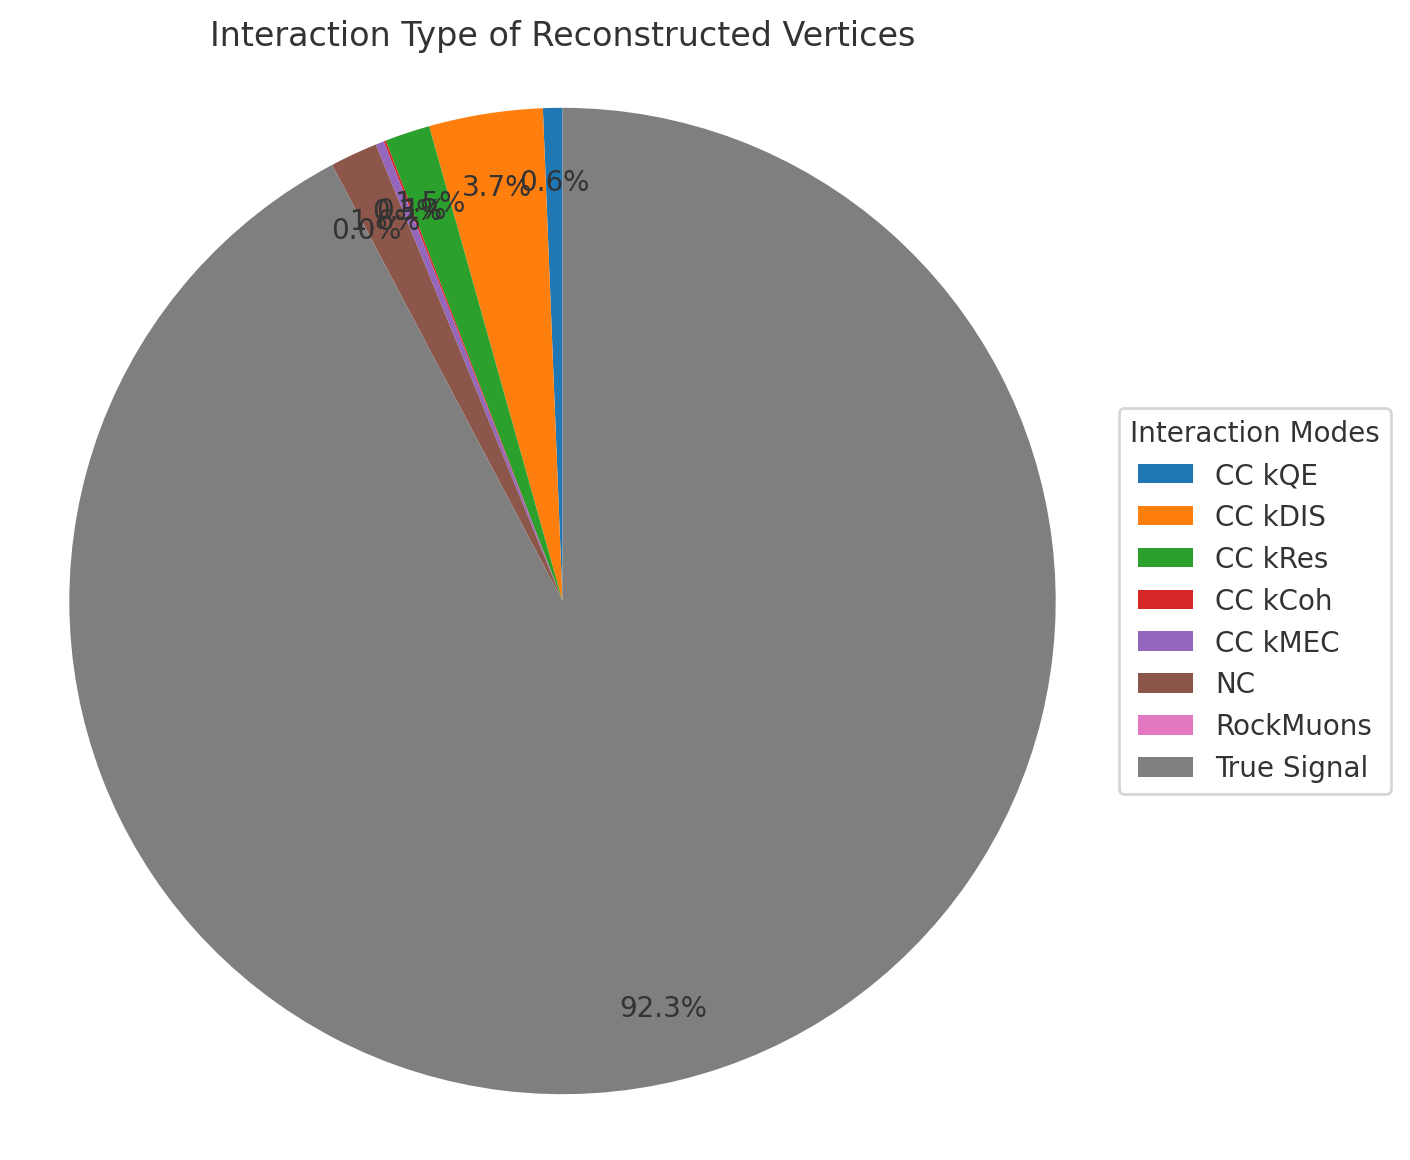

In [87]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode


prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0

# Constants and initialization
tpc_dist_qe=5

ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_data = []

ixn_dict={'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
          'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]}

#store track length and distance to vtx  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'pdgs':[],
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
}

sec_protons=0
c=0

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe,2, QE=False)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist_qe, mode='mx2',QE=False)
    match_vertices_signal = np.zeros_like(reco_vertices, dtype=bool)  
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)

    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx, match_vertices_signal = matching(ev_data, vtx_index, true_interactions, match_vertices_signal)
            if match: 
                #scan over particles of the event 
                count_match_FV += 1
                filtered_data.append(ev_data)
                #count type of interaction reconstructed in signal 
                insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                ixn_dict['file_number'].append(ev_data['file_number'])
                ixn_dict['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                ixn_dict['ixn_number'].append(vtx_index)
                ixn_dict['true_ixn_number'].append(best_match_idx)
                ixn_dict['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                ixn_dict['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
                ixn_dict['match'].append(1)
                ixn_dict['nprim'].append(ev_data['rec.mc.nu.nprim'][best_match_idx])
                ixn_dict['nsec'].append(ev_data['rec.mc.nu.nsec'][best_match_idx])
                ixn_dict['nproton'].append(ev_data['rec.mc.nu.nproton'][best_match_idx])
                ixn_dict['nneutron'].append(ev_data['rec.mc.nu.nneutron'][best_match_idx])
                ixn_dict['npip'].append(ev_data['rec.mc.nu.npip'][best_match_idx])
                ixn_dict['npim'].append(ev_data['rec.mc.nu.npim'][best_match_idx])
                ixn_dict['npi0'].append(ev_data['rec.mc.nu.npi0'][best_match_idx])
            elif best_match_idx is not None:
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )
                
                true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                sec_dic['track_neutron'] = []
                prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
                sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
            
                c +=1
                #true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                # for each vertex, scan over the particles
                reco_dic = part_scanner(ev_data,reco_data,vtx_index)
                num_recoprotons = len(reco_dic['best_match_type'])
                for index in range(num_recoprotons):
                    bm_ixn=reco_dic['best_match_ixn'][index]
                    bm_type=reco_dic['best_match_type'][index]
                    bm_idx=reco_dic['best_match_idx'][index]
                    parent_id = reco_dic['parent_id'][index]

                    reco_energy=reco_dic['energy']
                    track_length=reco_dic['length']
                    vtx_distance=reco_dic['distance']

                    #get the true info from best match 
                    bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                    bm_dic = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                    reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                    reco_proton_dic['best_match_type'].append(bm_dic['type'])
                    reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                    # reco_proton_dic['best_match_length'].append(bm_dic['length'])
                    # reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                    reco_proton_dic['vtx_t'].append(bm_ixn)
                    reco_proton_dic['parent_id'].append(parent_id)
                    #reco info
                    reco_proton_dic['reco_energy'].append(reco_energy)
                    reco_proton_dic['reco_length'].append(track_length)
                    reco_proton_dic['reco_distance'].append(vtx_distance)
                    reco_proton_dic['vtx_r'].append(vtx_index)
                    reco_proton_dic['ev'].append(ev)

                    if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                        sec_protons+=1
                        neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                        #print(bm_ixn, parent_id)
                        if neutron_induced:
                            sample_dic['reco_length'].append(track_length)
                            sample_dic['reco_distance'].append(vtx_distance)
                            sample_dic['reco_energy'].append(reco_energy)
                            sample_dic['best_match_energy'].append(bm_dic['energy'])
                            # sample_dic['best_match_length'].append(bm_dic['length'])
                            # sample_dic['best_match_distance'].append(bm_dic['distance'])

                

       
    num_match_signal +=np.sum(match_vertices_signal)
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
display_summary(e, p, scattering_counters, current_counters, insignal_counters)
plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
df_out = pd.DataFrame.from_dict(ixn_dict)
df_out.to_csv('MR6_QE_like_ixn.csv',index=False)

In [51]:
c

687

In [85]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode


prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0

# Constants and initialization
tpc_dist_qe=5

ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_data = []

ixn_dict={'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
          'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]}

#store track length and distance to vtx  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'pdgs':[],
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
}

sec_protons=0
c=0

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe,2, QE=False)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist_qe, mode='mx2',QE=False)
    match_vertices_signal = np.zeros_like(reco_vertices, dtype=bool)  
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)

    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx, match_vertices_signal = matching(ev_data, vtx_index, true_interactions, match_vertices_signal)
            if best_match_idx is not None: 
                true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                sec_dic['track_neutron'] = []
                prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
                sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
                c +=1
                #true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                # for each vertex, scan over the particles
                reco_dic = part_scanner(ev_data,reco_data,vtx_index)
                num_recoprotons = len(reco_dic['best_match_type'])
                for index in range(num_recoprotons):
                    bm_ixn=reco_dic['best_match_ixn'][index]
                    bm_type=reco_dic['best_match_type'][index]
                    bm_idx=reco_dic['best_match_idx'][index]
                    parent_id = reco_dic['parent_id'][index]

                    reco_energy=reco_dic['energy']
                    track_length=reco_dic['length']
                    vtx_distance=reco_dic['distance']

                    #get the true info from best match 
                    bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                    bm_dic = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                    reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                    reco_proton_dic['best_match_type'].append(bm_dic['type'])
                    reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                    # reco_proton_dic['best_match_length'].append(bm_dic['length'])
                    # reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                    reco_proton_dic['vtx_t'].append(bm_ixn)
                    reco_proton_dic['parent_id'].append(parent_id)
                    #reco info
                    reco_proton_dic['reco_energy'].append(reco_energy)
                    reco_proton_dic['reco_length'].append(track_length)
                    reco_proton_dic['reco_distance'].append(vtx_distance)
                    reco_proton_dic['vtx_r'].append(vtx_index)
                    reco_proton_dic['ev'].append(ev)

                    if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                        sec_protons+=1
                        neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                        #print(bm_ixn, parent_id)
                        if neutron_induced:
                            sample_dic['reco_length'].append(track_length)
                            sample_dic['reco_distance'].append(vtx_distance)
                            sample_dic['reco_energy'].append(reco_energy)
                            sample_dic['best_match_energy'].append(bm_dic['energy'])
                            # sample_dic['best_match_length'].append(bm_dic['length'])
                            # sample_dic['best_match_distance'].append(bm_dic['distance'])

                

       
    num_match_signal +=np.sum(match_vertices_signal)
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
# display_summary(e, p, scattering_counters, current_counters, insignal_counters)
# plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
# df_out = pd.DataFrame.from_dict(ixn_dict)
# df_out.to_csv('MR6_QE_like_ixn.csv',index=False)

n_pre 0
index in ev: [0, 9]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8]
index of ip in ev 2
particle 2 out of 9 has 5 overals and it is at 2 index
range: 2 7
[0.3809524  0.27450982 0.1875     0.02439024 0.01470588]
[18 19  2  7 14]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
First overlap: 4
particle 2 has best match primary 2212
 
n_pre 0
index in ev: [0, 9]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8]
index of ip in ev 3
particle 3 out of 9 has 2 overals and it is at 3 index
range: 7 9
[0.9425287  0.02803738]
[10 19]
First overlap: 0
First overlap: 1
particle 3 has best match primary 2212
 
n_pre 0
index in ev: [0, 9]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8]
index of ip in ev 4
particle 4 out of 9 has 5 overals and it is at 4 index
range: 9 14
[0.7692308  0.04255319 0.04       0.02439024 0.00763359]
[15 19 11 18  6]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
First overlap: 4
particle 4 has best match primary 2212
 
n_pre 0
index in ev: [0, 9]

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


n_pre 0
index in ev: [0, 9]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8]
index of ip in ev 7
particle 7 out of 9 has 2 overals and it is at 7 index
range: 13 15
[0.8942308  0.01351351]
[8 9]
First overlap: 0
First overlap: 1
particle 7 has best match seconday 2212
 
n_pre 0
index in ev: [0, 9]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8]
index of ip in ev 8
particle 8 out of 9 has 2 overals and it is at 8 index
range: 15 17
[0.9230769 0.0137931]
[9 8]
First overlap: 0
First overlap: 1
particle 8 has best match seconday 2212
 
n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 6
particle 0 out of 3 has 3 overals and it is at 6 index
range: 6 9
[0.78125    0.04651163 0.00564972]
[1 3 0]
First overlap: 0
First overlap: 1
First overlap: 2
particle 0 has best match primary 2212
 
n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 7
particle 1 out of 3 has 1 overals and it is at 7 index
range: 9 10
[0.94174755]
[3]
First overlap: 0
particle 1 has best match primar

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  ang_yz_diff = np.abs(np.arctan(mn_dy/mn_dz) - np.arctan(tpc_dy/tpc_dz))


n_pre 0
index in ev: [0, 11]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
index of ip in ev 6
particle 6 out of 11 has 6 overals and it is at 6 index
range: 10 16
[0.53061223 0.13043478 0.12068965 0.05660377 0.02040816 0.01538462]
[19 24 15 23  4  0]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
First overlap: 4
First overlap: 5
particle 6 has best match primary 2212
 
n_pre 0
index in ev: [0, 3]
actual range [0, 1, 2]
index of ip in ev 0
particle 0 out of 3 has 1 overals and it is at 0 index
range: 0 1
[0.93333334]
[4]
First overlap: 0
particle 0 has best match primary 2212
 
n_pre 0
index in ev: [0, 3]
actual range [0, 1, 2]
index of ip in ev 1
particle 1 out of 3 has 3 overals and it is at 1 index
range: 1 4
[0.9480519  0.01904762 0.00511509]
[2 4 0]
First overlap: 0
First overlap: 1
First overlap: 2
particle 1 has best match primary 2212
 
n_pre 0
index in ev: [0, 16]
actual range [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
index of ip in ev 15
p

In [86]:
reco_results =[]
proton_purity_secp = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_purity_np = round(len(sample_dic['reco_length'])/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_secp': len(reco_proton_dic['best_match_pdg']),
    'matched_secp': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity sp': proton_purity_secp,
    'purity np': proton_purity_np,
    'eff':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))



   reco_secp  matched_secp  neutron_induced  purity sp  purity np    eff
0      13197          7762             1231      0.588      0.093  0.612
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0     19552       3356       2013         695        162    1426    649
None


In [39]:
#Efficiency n->p = reco n->p / true n -> p 	
len(sample_dic['reco_length'])/ results_df['SecProton'][0]
#Purity n->p = matched n -> p / reco p 	
len(sample_dic['reco_length'])/len(reco_proton_dic['best_match_pdg'])



0.2608695652173913

In [55]:
c

2077

In [50]:
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0              1562                  422               95    0.27       0.505
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0      2422        292        188          43         30     170     46
None


In [9]:
results_all=reco_results_df

In [31]:
results = pd.concat([results_QE_non_exclusive,results_QE_exclusive] ,ignore_index=True)
results

,reco_sec_protons,matched_sec_protons,neutron_induced,purity,efficiency
0,15,13,11,0.867,0.194
1,65,60,43,0.923,0.341


In [42]:
# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,  proton_threshold=2, QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            #(ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )

        # Need to add a way to check protons below 40 MeV 
        for ix in range(ev_data['rec.mc.nu..length']):
            if mask_t[ix]: 
                n_particles = ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                    if pdg == pdg_tab.proton: 
                        xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                        ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                        zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                        xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                        ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                        ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                        track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                        if track_length > proton_threshold:
                            signal[ix] = False
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
                if pdg == pdg_tab.proton: 
                    xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                    ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                    zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                    xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                    ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                    ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                    track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                    if track_length > proton_threshold:
                        signal[ix] = False



    return signal

In [43]:
def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

results = [] # List to store the results for each mode
prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions=true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist=5,proton_threshold=2, QE=True)
    for inx, interaction_value in enumerate(true_interactions):
        if interaction_value:
            sec_dic['track_neutron'] = []
            prim_dic = particles_inx(ev_data, inx, 'prim', prim_dic)
            sec_dic = particles_inx(ev_data, inx, 'sec', sec_dic)
            neutron_particle_count = Counter(sec_dic['track_neutron'])
            for count in neutron_particle_count.values():
                if count > 1: multi += 1
                elif count == 1: single += 1
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0       946        129         74          29          5      59     27


Counter({2212: 74,
         2112: 29,
         1000010020: 6,
         111: 6,
         22: 5,
         -211: 5,
         11: 3,
         1000010030: 1})

In [39]:
print(results_df) #con np=0 true y la condicion nueva

   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0       405         84         53          18          1      40     17


In [44]:
print(results_df) #sin np=0 true y la condicion nueva

   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0       946        129         74          29          5      59     27


# Plots for presentation

In [3]:
tpc_dist = 5


# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal

# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,proton_threshold=2,QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            (ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )

        # Need to add a way to check protons below 40 MeV 
        for ix in range(ev_data['rec.mc.nu..length']):
            if mask_t[ix]: 
                n_particles = ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                    if pdg == pdg_tab.proton: 
                        xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                        ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                        zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                        xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                        ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                        ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                        track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                        if track_length > proton_threshold:
                            signal[ix] = False
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=True):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv, True)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

# Step 2.5 select tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out


def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv, exclusive=True):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count_prim = 0
        count_sec = 0 

        if(exclusive):
            for ip in range(n_pre,n_pre+n_vtx):
                count_prim += ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                count_sec += 1 if not ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0 
        
            if count_prim == 1 and count_sec==1:
                continue
            else:
                QE_signal[vtx] = 0
        else:
            for ip in range(n_pre, n_pre+n_vtx):
                count_prim +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                if count_prim > 1: break 
            if count_prim != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal, reco_vertices_signal):

    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_ixn = None
    # max_overlap = 0
    # best_match_idx = 0
    # best_match_ixn = 0 
    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_ixn = temp_tp_ixn

    if best_match_ixn is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_ixn] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            reco_vertices_signal[vtx_index] = True
            return True, best_match_ixn, reco_vertices_signal
    return False, best_match_ixn, reco_vertices_signal

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type - Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Interaction Type - Correctly Reconstructed Interactions Vertices')
    plt.axis('equal')
    plt.show()


def display_summary(efficiency, purity, scattering_counters, current_counters, insignal_counters):
# Print and plot results    
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")
    
def get_trk_length(start_point,end_point):
    dx = start_point[0][:] - end_point[0][:]
    dy = start_point[1][:] - end_point[1][:]
    dz = start_point[2][:] - end_point[2][:]
    trk_length = np.sqrt( np.square(dx) + np.square(dy) + np.square(dz))
    return trk_length


# ------------------------- NEUTRON SELECTION FUNCTIONS ----------------------
# ----------------------------------------------------------------------------

def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def around_vtx_region(part_pos, vtx_pos, radius):
    """Check if a particle position is outside a 
    spherical exclusion region around the vertex."""
    distance = np.linalg.norm(np.array(part_pos) - np.array(vtx_pos))
    return distance > radius

def around_track_region(point, xs, xe, radius):
    """Check if a point is outside a cylinder with a 
    given radius around muon track."""
    point = np.array(point)
    xs = np.array(xs)
    xe = np.array(xe)
    line_vec = xe - xs
    point_vec = point - xs
    line_length = np.linalg.norm(line_vec)

    if line_length == 0:
        raise ValueError("Track length should not be zero.")
    else:
        line_unit_vec = line_vec / line_length
        projection_length = np.dot(point_vec, line_unit_vec)
        projection_length = np.clip(projection_length, 0, line_length)
        closest_point = xs + projection_length * line_unit_vec
        distance_to_line = np.linalg.norm(point - closest_point)
    
    return distance_to_line > radius


def muon_track_info(reco_info, true_info):
    #primary muon track of the interaction
    muon_track_mask = (
                (reco_info['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
                (reco_info['rec.common.ixn.dlp.part.dlp.pdg']== pdg_tab.muon)
    )
    muon_sx = reco_info['rec.common.ixn.dlp.part.dlp.start.x'][muon_track_mask]
    muon_sy = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_sz = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_ex = reco_info['rec.common.ixn.dlp.part.dlp.end.x'][muon_track_mask]
    muon_ey = reco_info['rec.common.ixn.dlp.part.dlp.end.y'][muon_track_mask]
    muon_ez = reco_info['rec.common.ixn.dlp.part.dlp.end.z'][muon_track_mask]        
    start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    return start_point, end_point

def part_scanner(ev_data,reco_data, vtx, r_sph=0,r_cil=0, verbose=True):
    track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None, None
    #if (verbose): print(f'Selecting particles {r_sph} cm away vertex and {r_cil} cm around muon track')
    #muon_track_start, muon_track_end  = muon_track_info(reco_data, true_data)
    n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])

    #store the reco particles of the current vertex vtx
    reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[]}

    for ip in range(n_part):
        vtx_pos = [
                reco_data['rec.common.ixn.dlp.vtx.x'],
                reco_data['rec.common.ixn.dlp.vtx.y'], 
                reco_data['rec.common.ixn.dlp.vtx.z']
            ]
        ip_start = [
            reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ]
        ip_end = [
            reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ]
        # Check if the particle is in ROI
        in_FV = isContainedFV(ip_start)
        outside_vtx = around_vtx_region(ip_start, vtx_pos, r_sph)
        #outside_track = around_track_region(ip_start, muon_track_start, muon_track_end, r_cil)
        
        if outside_vtx and in_FV: #and outside_track and in_FV:
            ip_pdg = reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            is_primary = reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
            
            # if secondary proton, find the match
            if (ip_pdg==pdg_tab.proton) and (is_primary==False): 
                #if (is_primary==False): 
                    best_match_type, best_match_ixn, best_match_idx, parent_id= match_finder(ev_data, reco_data, vtx,ip)          
                    track_length, vtx_distance = calculate_track_properties(ip_start, ip_end, vtx_pos)
                    if best_match_type is not None:
                        reco_dic['best_match_type'].append(best_match_type)
                        reco_dic['best_match_ixn'].append(best_match_ixn)
                        reco_dic['best_match_idx'].append(best_match_idx)
                        reco_dic['parent_id'].append(parent_id)
                        reco_dic['length'].append(track_length)
                        reco_dic['distance'].append(vtx_distance)
                        reco_dic['energy'].append(reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])

                    #else: continuet_match_type'].append(best_match_type)
                        reco_dic['best_match_ixn'].append(best_match_ixn)
                        reco_dic['best_match_idx'].append(best_match_idx)
                        reco_dic['parent_id'].append(parent_id)
                        reco_dic['length'].append(track_length)
                        reco_dic['distance'].append(vtx_distance)
                        reco_dic['energy'].append(reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])

                    #else: continue
    return reco_dic


def match_finder(ev_data, reco_data, vtx, ip):
    best_match_type = None
    best_match_ixn=None
    best_match_idx=None
    parent_id=None

    max_overlap=0
    n_part= ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
    print('n_pre',n_pre)
    idx_ev= [n_pre, n_pre+n_part]
    print('index in ev:',idx_ev)
    idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
    print('actual range' , idx_ev_data)
    n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    ip_ev = idx_ev_data[ip]
    print('index of ip in ev',ip_ev)
    print(f'particle {ip} out of {n_part} has {n_overlaps} overals and it is at {ip_ev} index')
    if ip_ev ==0 : truth_pre = 0
    else: truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
    print('range:',truth_pre,truth_pre+n_overlaps)
    overlaps=ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
    print(overlaps)
    matches = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
    print(matches)
    types = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
    #print(types)
    ixns = ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
    #print(ixns)
    for tp in range(n_overlaps):
        print('First overlap:', tp)
        temp_overlap=overlaps[tp]
        temp_tp_match=matches[tp]
        temp_tp_type=types[tp]
        temp_tp_ixn=ixns[tp]
        if(temp_overlap>max_overlap):
            max_overlap=temp_overlap
            best_match_idx=temp_tp_match
            best_match_type=temp_tp_type
            best_match_ixn=temp_tp_ixn

    if(best_match_type==3):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nsec'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nsec'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        parent_id = ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match seconday {best_match_pdg}\n ')
    if(best_match_type==1):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nprim'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nprim'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match primary {best_match_pdg}\n ')


    return best_match_type, best_match_ixn, best_match_idx, parent_id



def get_bm_truth_data(bm_truth_data,bm_type, bm_idx):
    bm_dic={'type': bm_type}

    if bm_type ==1: 
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(
            (  
                bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        
        # bm_dic['length'] = track_length_truth
        # bm_dic['distance'] = vtx_distance_truth
        
    elif(bm_type==3):
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
        bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(

            (  
                bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        # bm_dic['length'] = track_length_truth
        # bm_dic['distance'] = vtx_distance_truth

    return bm_dic


# TRUE NEUTRINO MULTIPLICITY HERE

def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

In [30]:
def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

results = [] # List to store the results for each mode
prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0
num_int= 0

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions=true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist=5, QE=True)
    for inx, interaction_value in enumerate(true_interactions):
        num_int += 1
        if interaction_value:
            sec_dic['track_neutron'] = []
            prim_dic = particles_inx(ev_data, inx, 'prim', prim_dic)
            sec_dic = particles_inx(ev_data, inx, 'sec', sec_dic)
            neutron_particle_count = Counter(sec_dic['track_neutron'])
            for count in neutron_particle_count.values():
                if count > 1: multi += 1
                elif count == 1: single += 1
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0      2017        417        252         109         14     194     87


Counter({2212: 252,
         2112: 109,
         22: 14,
         1000010020: 13,
         111: 10,
         -211: 10,
         11: 7,
         211: 2})

In [5]:
tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163

In [12]:
# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,mode=None): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)
    mask_t = (
        (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
        (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
        (ev_data['rec.mc.nu.iscc'] == 1) &
        (abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu) #&
 #       (ev_data['rec.mc.nu.mode']==1)  
    )

    if mode is not None:
        mask_t &= (ev_data['rec.mc.nu.mode'] == mode)

    signal[mask_t] = True
    
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if pdg == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=False):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

# Step 2.5 select tracks th	ScatteringMode {
#   kUnknownMode = -100 , kQE = 1 , kSingleKaon = 2 , kDIS = 3 ,
#   kRes = 4 , kCoh = 5 , kDiffractive = 6 , kNuElectronElastic = 7 ,
#   kInvMuonDecay = 8 , kAMNuGamma = 9 , kMEC = 10 , kCohElastic = 11 ,
#   kInverseBetaDecay = 12 , kGlashowResonance = 13 , kIMDAnnihilation = 14 , kPhotonCoh = 15 ,
#   kPhotonRes = 16 , kDarkMatterElastic = 101 , kDarkMatterDIS = 102 , kDarkMatterElectron = 103 }
 
# Tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out

# Tracks with match 2x2
def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count = 0
        for ip in range(n_pre, n_pre+n_vtx):
            count +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
            if count > 1: break 
        if count != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal):
    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_idx = None

    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_ixn

    if best_match_idx is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            return True, best_match_idx
    return False, best_match_idx

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Scattering Mode of Vertices Matching Signal')
    plt.axis('equal')
    plt.show()

#Print and plot results    
def display_summary(efficiency, purity, scattering_counters, current_counters):
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encount

There are 8674 reconstructed vertices.
There are 8014 reco vertices matching true interaction signal.
There are 12846 true interactions
Interaction Summary:
1: 8.33%
3: 47.58%
4: 19.24%
5: 0.91%
10: 3.48%
0: 20.45%
2: 0.00%

Efficiency: 62.39%
Purity: 92.39%


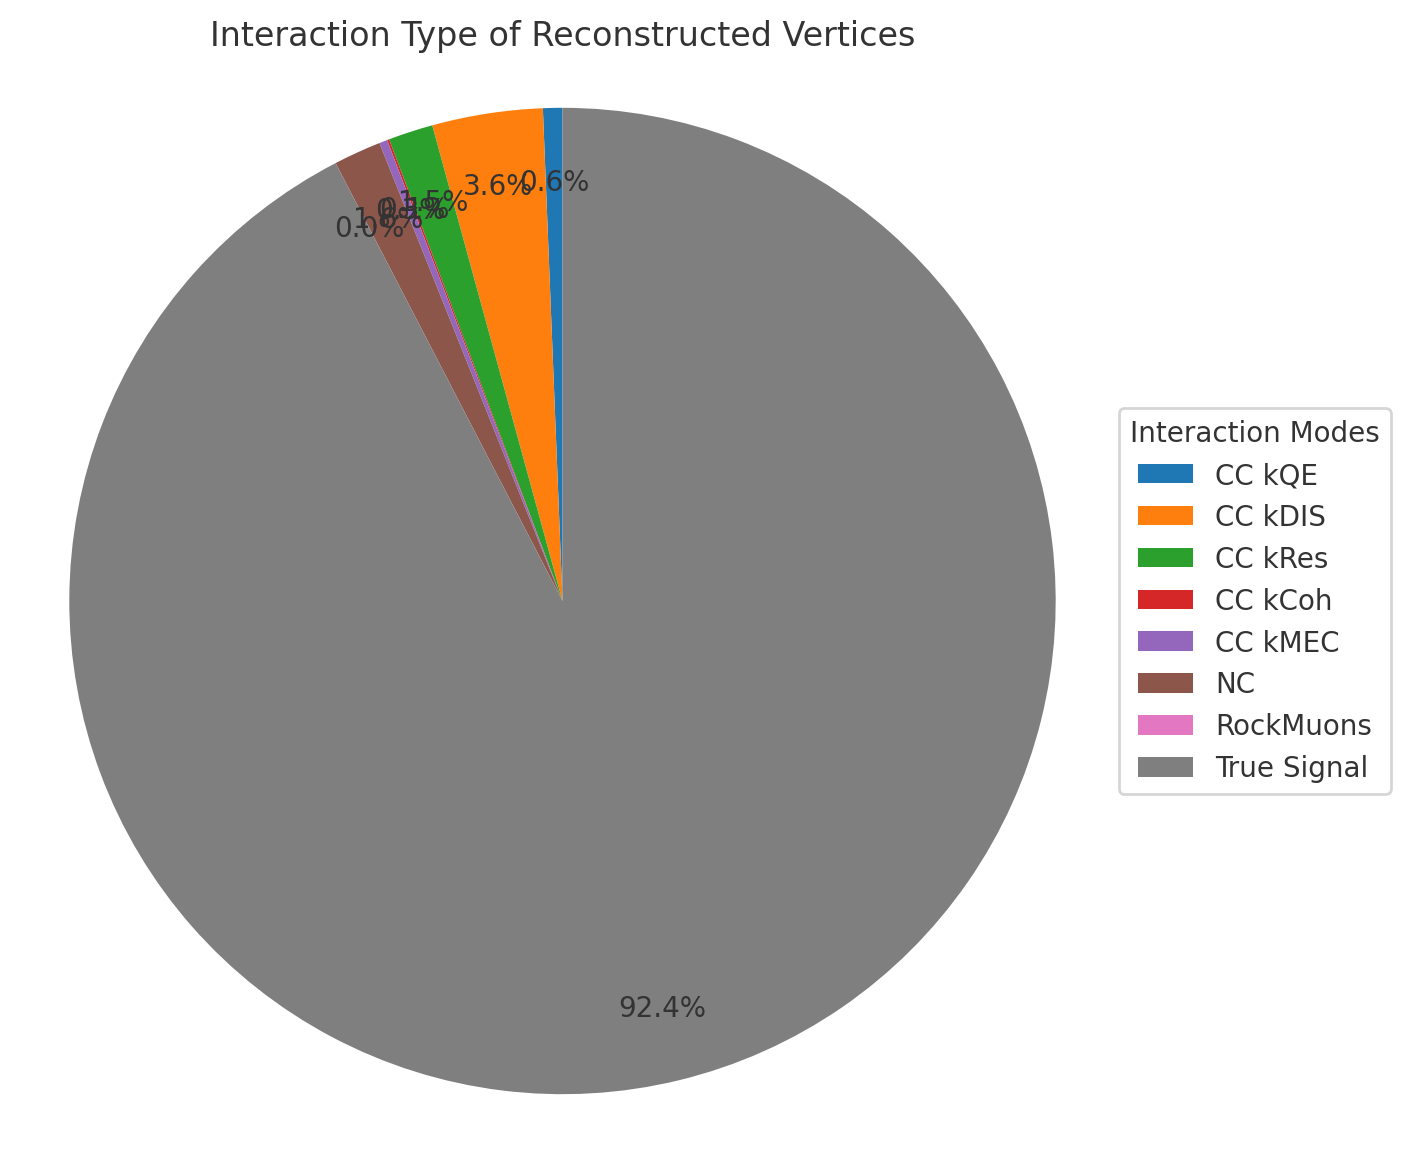

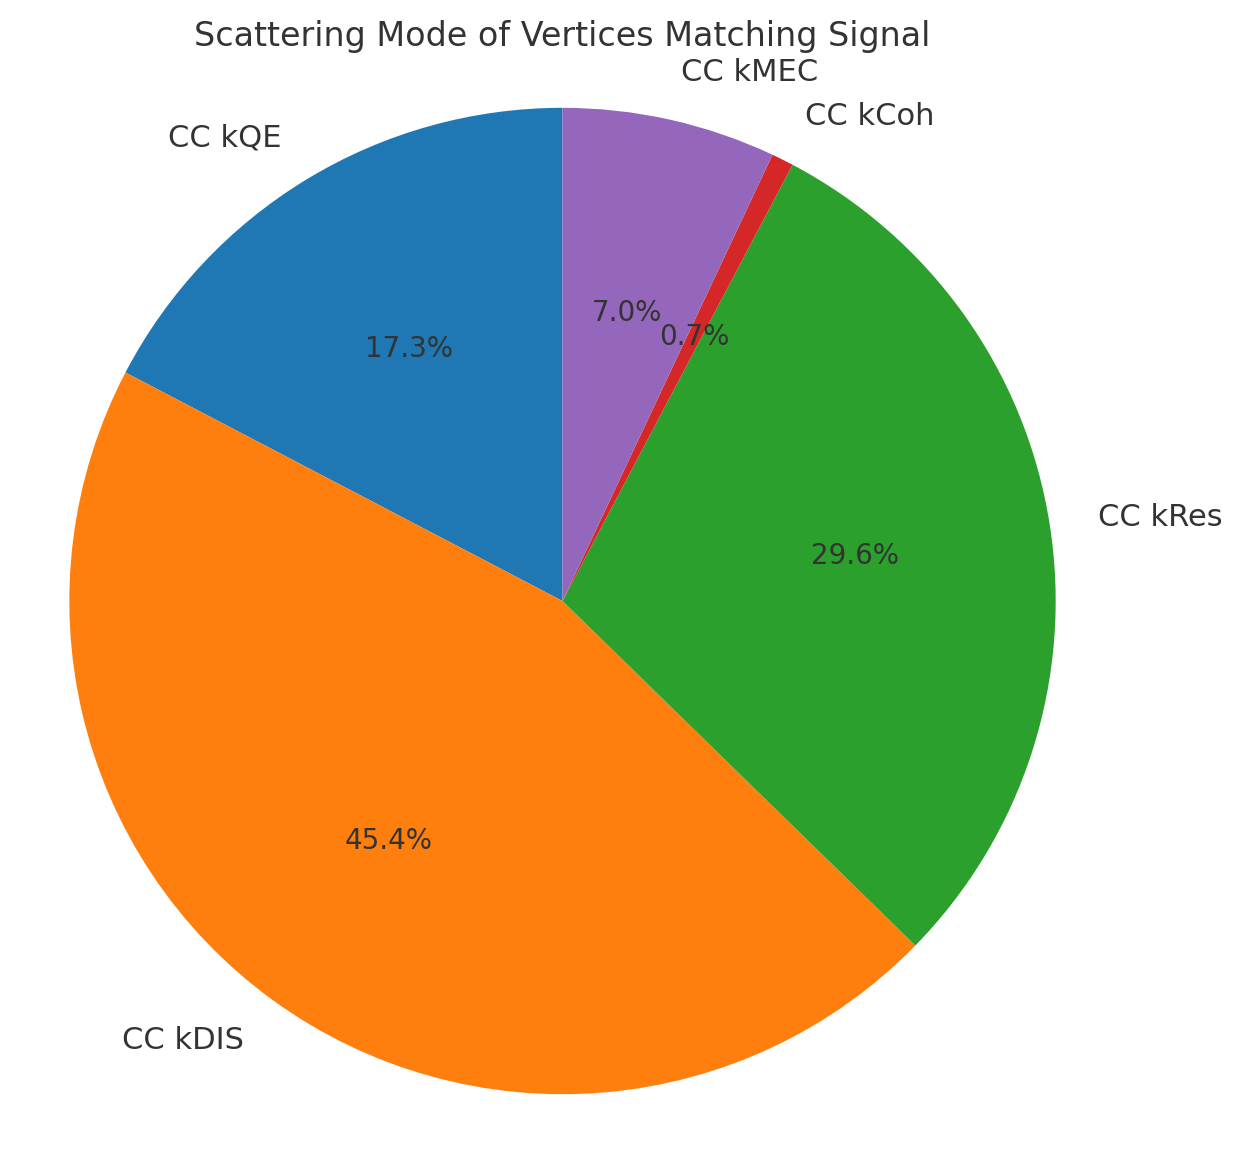

'/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/neutrino_signal.csv'

In [13]:
# Constants and initialization
ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_indices = []

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    #get true signal and reco vertices
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode='mx2',QE=False)
    match_vertices_signal = reco_vertices.copy() 
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)
    
    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx = matching(ev_data, vtx_index, true_interactions)
            if match: 
                count_match_FV += 1
                filtered_indices.append(ev)
                #count type of interaction reconstructed in signal 
                insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1    
            elif best_match_idx is not None:
                match_vertices_signal[vtx_index] = False  
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )
    num_match_signal +=np.sum(match_vertices_signal)


print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
display_summary(e, p, scattering_counters, current_counters)
plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
plot_signal_interactions(ScatteringMode, insignal_counters)

# Create filtered DataFrame from original `df` based on indices that passed filter
filtered_data_df = df.iloc[filtered_indices]
# Save filtered data to a CSV file
file_path = '/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/neutrino_signal.csv'
filtered_data_df.to_csv(file_path, index=False)
file_path

# CM meeting


In [4]:
tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163

# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal

# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist, proton_threshold=2, QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            #(ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
                if pdg == pdg_tab.proton: 
                    xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                    ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                    zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                    xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                    ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                    ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                    track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                    if track_length > proton_threshold:
                        signal[ix] = False
    return signal

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=False):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv, False)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

# Step 2.5 select tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out


def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv, exclusive=True):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count_prim = 0
        count_sec = 0 

        if(exclusive):
            for ip in range(n_pre,n_pre+n_vtx):
                count_prim += ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                count_sec += 1 if not ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0 

            if count_prim == 1 and count_sec ==1:
                continue
            else:
                QE_signal[vtx] = 0
        else:
            for ip in range(n_pre, n_pre+n_vtx):
                count_prim +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                if count_prim > 1: break 
            if count_prim != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal, reco_vertices_signal):

    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_idx = None

    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_idx = temp_tp_ixn

    if best_match_idx is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_idx] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            reco_vertices_signal[vtx_index] = True
            return True, best_match_idx, reco_vertices_signal
    return False, best_match_idx, reco_vertices_signal

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Scattering Mode of Vertices Matching Signal')
    plt.axis('equal')
    plt.show()


def display_summary(efficiency, purity, scattering_counters, current_counters, insignal_counters):
# Print and plot results    
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")
    
def get_trk_length(start_point,end_point):
    dx = start_point[0][:] - end_point[0][:]
    dy = start_point[1][:] - end_point[1][:]
    dz = start_point[2][:] - end_point[2][:]
    trk_length = np.sqrt( np.square(dx) + np.square(dy) + np.square(dz))
    return trk_length

def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def around_vtx_region(part_pos, vtx_pos, radius):
    """Check if a particle position is outside a 
    spherical exclusion region around the vertex."""
    distance = np.linalg.norm(np.array(part_pos) - np.array(vtx_pos))
    return distance > radius

def around_track_region(point, xs, xe, radius):
    """Check if a point is outside a cylinder with a 
    given radius around muon track."""
    point = np.array(point)
    xs = np.array(xs)
    xe = np.array(xe)
    line_vec = xe - xs
    point_vec = point - xs
    line_length = np.linalg.norm(line_vec)

    if line_length == 0:
        raise ValueError("Track length should not be zero.")
    else:
        line_unit_vec = line_vec / line_length
        projection_length = np.dot(point_vec, line_unit_vec)
        projection_length = np.clip(projection_length, 0, line_length)
        closest_point = xs + projection_length * line_unit_vec
        distance_to_line = np.linalg.norm(point - closest_point)
    
    return distance_to_line > radius


def muon_track_info(reco_info, true_info):
    #primary muon track of the interaction
    muon_track_mask = (
                (reco_info['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
                (reco_info['rec.common.ixn.dlp.part.dlp.pdg']== pdg_tab.muon)
    )
    muon_sx = reco_info['rec.common.ixn.dlp.part.dlp.start.x'][muon_track_mask]
    muon_sy = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_sz = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_ex = reco_info['rec.common.ixn.dlp.part.dlp.end.x'][muon_track_mask]
    muon_ey = reco_info['rec.common.ixn.dlp.part.dlp.end.y'][muon_track_mask]
    muon_ez = reco_info['rec.common.ixn.dlp.part.dlp.end.z'][muon_track_mask]        
    start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    return start_point, end_point

def part_scanner(ev_data,reco_data, true_data,vtx, r_sph=0,r_cil=0, verbose=True):
    reco_energy, track_length, vtx_distance, best_match_pdg, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None,None, None, None
    #if (verbose): print(f'Selecting particles {r_sph} cm away vertex and {r_cil} cm around muon track')
    muon_track_start, muon_track_end  = muon_track_info(reco_data, true_data)
    n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])
    for ip in range(n_part):
        vtx_pos = [
                reco_data['rec.common.ixn.dlp.vtx.x'],
                reco_data['rec.common.ixn.dlp.vtx.y'], 
                reco_data['rec.common.ixn.dlp.vtx.z']
            ]
        ip_start = [
            reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ]
        ip_end = [
            reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ]
        # Check if the particle is in ROI
        outside_vtx = around_vtx_region(ip_start, vtx_pos, r_sph)
        #outside_track = around_track_region(ip_start, muon_track_start, muon_track_end, r_cil)
        in_FV = isContainedFV(ip_start)
        if outside_vtx and in_FV: #and outside_track and in_FV:
            ip_pdg = reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            is_primary = reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
#         if(is_primary==False): continue 
            #if(verbose): print(f"Particle {ip} is a {ip_pdg}")
            if (ip_pdg==pdg_tab.proton) and (is_primary==False):
            #print('primary found')
                best_match_pdg, best_match_type, best_match_ixn, best_match_idx, parent_id= match_finder(ev_data, reco_data, vtx,ip)          
                track_length, vtx_distance = calculate_track_properties(ip_start, ip_end, vtx_pos)
                reco_energy = reco_data['rec.common.ixn.dlp.part.dlp.E'][ip]
        else: continue
    return reco_energy, track_length, vtx_distance, best_match_pdg, best_match_type, best_match_ixn, best_match_idx, parent_id


def match_finder(ev_data, reco_data, vtx, ip):
    best_match_pdg=None
    best_match_type = None
    best_match_ixn=None
    best_match_idx=None
    parent_id=None
    n_part=ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
    idx_ev_data = [n_pre, n_pre+n_part-1]
    max_overlap=0
    #print(ip)
    ip_ev = idx_ev_data[ip]
    #print('range in ev_data:', idx_ev_data, ip_ev) 
    n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    reco_pdg= reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
    truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev])
    #print(ip_ev)
    #print(truth_pre, truth_pre+ n_overlaps)
    overlaps=ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
    matches = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
    #print(matches)
    types = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
    ixns = ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
    #print(ixns)
    for tp in range(n_overlaps):
        temp_overlap=overlaps[tp]
        temp_tp_match=matches[tp]
        temp_tp_type=types[tp]
        temp_tp_ixn=ixns[tp]
        if(temp_overlap>max_overlap):
            max_overlap=temp_overlap
            best_match_idx=temp_tp_match
            best_match_type=temp_tp_type
            best_match_ixn=temp_tp_ixn
            #print('temp overlap:',max_overlap)
        #print(f'{tp} overlap: {temp_overlap}')
    #print(f'Final overlap {max_overlap}')

    # if best_match_ixn is not None: 
    #     true_data_bm = caf_reader.get_true_data(ev_data, best_match_ixn)
    if(best_match_type==3):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nsec'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nsec'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        parent_id = ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} is a reco {reco_pdg} with best match seconday {best_match_pdg}\n ')
    if(best_match_type==1):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nprim'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nprim'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        #parent_id = df['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} is a reco {reco_pdg} with best match primary {best_match_pdg}\n ')

    return best_match_pdg, best_match_type, best_match_ixn, best_match_idx, parent_id


def get_bm_truth_data(bm_truth_data,bm_type, bm_idx):
    if bm_type ==1: 
        best_match_energy= bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(
            (  
                bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
    elif(bm_type==3):
        best_match_energy= bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(

            (  
                bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
    return best_match_energy, track_length_truth, vtx_distance_truth


# TRUE NEUTRINO MULTIPLICITY HERE

from collections import Counter

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic


In [5]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode

#for key, value in ScatteringMode.items():
    
prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0


# Constants and initialization
tpc_dist_qe=8

ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_data = []

ixn_dict={'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
          'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]}

#store track length and distance to vtx  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
}

c=0
sec_protons=0


for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe, QE=True)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist_qe, mode='mx2',QE=True)
    match_vertices_signal = np.zeros_like(reco_vertices, dtype=bool)  
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)

    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx, match_vertices_signal = matching(ev_data, vtx_index, true_interactions, match_vertices_signal)
            if match: 
                
                #scan over particles of the event 
                count_match_FV += 1
                filtered_data.append(ev_data)
                #count type of interaction reconstructed in signal 
                insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                ixn_dict['file_number'].append(ev_data['file_number'])
                ixn_dict['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                ixn_dict['ixn_number'].append(vtx_index)
                ixn_dict['true_ixn_number'].append(best_match_idx)
                ixn_dict['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                ixn_dict['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
                ixn_dict['match'].append(1)
                ixn_dict['nprim'].append(ev_data['rec.mc.nu.nprim'][best_match_idx])
                ixn_dict['nsec'].append(ev_data['rec.mc.nu.nsec'][best_match_idx])
                ixn_dict['nproton'].append(ev_data['rec.mc.nu.nproton'][best_match_idx])
                ixn_dict['nneutron'].append(ev_data['rec.mc.nu.nneutron'][best_match_idx])
                ixn_dict['npip'].append(ev_data['rec.mc.nu.npip'][best_match_idx])
                ixn_dict['npim'].append(ev_data['rec.mc.nu.npim'][best_match_idx])
                ixn_dict['npi0'].append(ev_data['rec.mc.nu.npi0'][best_match_idx])

                #if the interaction has a match, then use it 
                true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)

                #match of particle 
                reco_energy, track_length, vtx_distance,bm_pdg, bm_type, bm_ixn, bm_idx, parent_id =part_scanner(ev_data,reco_data,true_data,vtx_index)
                if (bm_pdg!= None) and  (bm_type!= None): #then particle had a match 

                    bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                    best_match_energy, track_length_truth, vtx_distance_truth = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                    reco_proton_dic['best_match_pdg'].append(bm_pdg)
                    reco_proton_dic['best_match_type'].append(bm_type)
                    reco_proton_dic['best_match_length'].append(track_length_truth)
                    reco_proton_dic['best_match_distance'].append(vtx_distance_truth)
                    reco_proton_dic['best_match_energy'].append(best_match_energy)
                    reco_proton_dic['vtx_t'].append(bm_ixn)
                    reco_proton_dic['parent_id'].append(parent_id)
                    
                    
                    #reco info
                    reco_proton_dic['reco_energy'].append(reco_energy)
                    reco_proton_dic['reco_length'].append(track_length)
                    reco_proton_dic['reco_distance'].append(vtx_distance)
                    reco_proton_dic['vtx_r'].append(vtx_index)
                    reco_proton_dic['ev'].append(ev)

                    if (bm_pdg==pdg_tab.proton) and (bm_type ==3): 
                        sec_protons+=1
                        neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                        print(bm_ixn, parent_id)
                        if neutron_induced:
                            sample_dic['reco_length'].append(track_length)
                            sample_dic['reco_distance'].append(track_length)
                            sample_dic['reco_energy'].append(reco_energy)
                            sample_dic['best_match_energy'].append(best_match_energy)
                            sample_dic['best_match_distance'].append(vtx_distance_truth)
                            sample_dic['best_match_length'].append(track_length_truth)    
                    

                sec_dic['track_neutron'] = []
                prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
                sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
                    
            elif best_match_idx is not None:
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )
                # ixn_dict['file_number'].append(ev_data['file_number'])
                # ixn_dict['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                # ixn_dict['ixn_number'].append(vtx_index)
                # ixn_dict['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                # ixn_dict['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
                # ixn_dict['match'].append(0)
                # ixn_dict['nprim'].append(ev_data['rec.mc.nu.nprim'][best_match_idx])
                # ixn_dict['nsec'].append(ev_data['rec.mc.nu.nsec'][best_match_idx])
                # ixn_dict['nproton'].append(ev_data['rec.mc.nu.nproton'][best_match_idx])
                # ixn_dict['nneutron'].append(ev_data['rec.mc.nu.nneutron'][best_match_idx])
                # ixn_dict['npip'].append(ev_data['rec.mc.nu.npip'][best_match_idx])
                # ixn_dict['npim'].append(ev_data['rec.mc.nu.npim'][best_match_idx])
                # ixn_dict['npi0'].append(ev_data['rec.mc.nu.npi0'][best_match_idx])
    
    num_match_signal +=np.sum(match_vertices_signal)
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
display_summary(e, p, scattering_counters, current_counters, insignal_counters)
plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
df_out = pd.DataFrame.from_dict(ixn_dict)
df_out.to_csv('MR6_QE_like_ixn.csv',index=False)

IndexError: list index out of range

In [13]:
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

#case for sec = 1 prim =1

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0                21                   13               13   0.619       0.206
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0       717         96         63          22          4      57     15
None


In [44]:
# #first lets look for reco interactions that produced more than one proton

tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163

# ----------- NEUTRINO SELECTION FUNCTIONS ------------------------------------
# -----------------------------------------------------------------------------


# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal

# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,proton_threshold=2,QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            #(ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )

        # Need to add a way to check protons below 40 MeV 
        for ix in range(ev_data['rec.mc.nu..length']):
            if mask_t[ix]: 
                n_particles = ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                    if pdg == pdg_tab.proton: 
                        xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                        ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                        zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                        xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                        ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                        ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                        track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                        if track_length > proton_threshold:
                            signal[ix] = False
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=True):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv, True)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

# Step 2.5 select tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out


def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv, exclusive=True):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count_prim = 0
        count_sec = 0 

        if(exclusive):
            for ip in range(n_pre,n_pre+n_vtx):
                count_prim += ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                count_sec += 1 if not ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0 
        
            if count_prim == 1 and count_sec==1:
                continue
            else:
                QE_signal[vtx] = 0
        else:
            for ip in range(n_pre, n_pre+n_vtx):
                count_prim +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                if count_prim > 1: break 
            if count_prim != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal, reco_vertices_signal):

    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_ixn = None
    # max_overlap = 0
    # best_match_idx = 0
    # best_match_ixn = 0 
    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_ixn = temp_tp_ixn

    if best_match_ixn is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_ixn] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            reco_vertices_signal[vtx_index] = True
            return True, best_match_ixn, reco_vertices_signal
    return False, best_match_ixn, reco_vertices_signal

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Scattering Mode of Vertices Matching Signal')
    plt.axis('equal')
    plt.show()


def display_summary(efficiency, purity, scattering_counters, current_counters, insignal_counters):
# Print and plot results    
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")
    
def get_trk_length(start_point,end_point):
    dx = start_point[0][:] - end_point[0][:]
    dy = start_point[1][:] - end_point[1][:]
    dz = start_point[2][:] - end_point[2][:]
    trk_length = np.sqrt( np.square(dx) + np.square(dy) + np.square(dz))
    return trk_length


# ------------------------- NEUTRON SELECTION FUNCTIONS ----------------------
# ----------------------------------------------------------------------------

def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def around_vtx_region(part_pos, vtx_pos, radius):
    """Check if a particle position is outside a 
    spherical exclusion region around the vertex."""
    distance = np.linalg.norm(np.array(part_pos) - np.array(vtx_pos))
    return distance > radius

def around_track_region(point, xs, xe, radius):
    """Check if a point is outside a cylinder with a 
    given radius around muon track."""
    point = np.array(point)
    xs = np.array(xs)
    xe = np.array(xe)
    line_vec = xe - xs
    point_vec = point - xs
    line_length = np.linalg.norm(line_vec)

    if line_length == 0:
        raise ValueError("Track length should not be zero.")
    else:
        line_unit_vec = line_vec / line_length
        projection_length = np.dot(point_vec, line_unit_vec)
        projection_length = np.clip(projection_length, 0, line_length)
        closest_point = xs + projection_length * line_unit_vec
        distance_to_line = np.linalg.norm(point - closest_point)
    
    return distance_to_line > radius


def muon_track_info(reco_info, true_info):
    #primary muon track of the interaction
    muon_track_mask = (
                (reco_info['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
                (reco_info['rec.common.ixn.dlp.part.dlp.pdg']== pdg_tab.muon)
    )
    muon_sx = reco_info['rec.common.ixn.dlp.part.dlp.start.x'][muon_track_mask]
    muon_sy = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_sz = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_ex = reco_info['rec.common.ixn.dlp.part.dlp.end.x'][muon_track_mask]
    muon_ey = reco_info['rec.common.ixn.dlp.part.dlp.end.y'][muon_track_mask]
    muon_ez = reco_info['rec.common.ixn.dlp.part.dlp.end.z'][muon_track_mask]        
    start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    return start_point, end_point

def part_scanner(ev_data,reco_data, vtx, r_sph=0,r_cil=0, verbose=True):
    track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None, None
    #if (verbose): print(f'Selecting particles {r_sph} cm away vertex and {r_cil} cm around muon track')
    #muon_track_start, muon_track_end  = muon_track_info(reco_data, true_data)
    n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])

    #store the reco particles of the current vertex vtx
    reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[]}

    for ip in range(n_part):
        vtx_pos = [
                reco_data['rec.common.ixn.dlp.vtx.x'],
                reco_data['rec.common.ixn.dlp.vtx.y'], 
                reco_data['rec.common.ixn.dlp.vtx.z']
            ]
        ip_start = [
            reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ]
        ip_end = [
            reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ]
        # Check if the particle is in ROI
        in_FV = isContainedFV(ip_start)
        outside_vtx = around_vtx_region(ip_start, vtx_pos, r_sph)
        #outside_track = around_track_region(ip_start, muon_track_start, muon_track_end, r_cil)
        
        if outside_vtx and in_FV: #and outside_track and in_FV:
            ip_pdg = reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            is_primary = reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
        
            # if secondary proton, find the match
            if (ip_pdg==pdg_tab.proton) and (is_primary==False): 
                    best_match_type, best_match_ixn, best_match_idx, parent_id= match_finder(ev_data, reco_data, vtx,ip)          
                    # track_length, vtx_distance = calculate_track_properties(ip_start, ip_end, vtx_pos)
                    if best_match_type is not None:
                        best_match_type, best_match_ixn, best_match_idx, parent_id= match_finder(ev_data, reco_data, vtx,ip)          
                        track_length, vtx_distance = calculate_track_properties(ip_start, ip_end, vtx_pos)
                        if best_match_type is not None:
                            reco_dic['best_match_type'].append(best_match_type)
                            reco_dic['best_match_ixn'].append(best_match_ixn)
                            reco_dic['best_match_idx'].append(best_match_idx)
                            reco_dic['parent_id'].append(parent_id)
                            reco_dic['length'].append(track_length)
                            reco_dic['distance'].append(vtx_distance)
                            reco_dic['energy'].append(reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])

                        #else: continuet_match_type'].append(best_match_type)
                            reco_dic['best_match_ixn'].append(best_match_ixn)
                            reco_dic['best_match_idx'].append(best_match_idx)
                            reco_dic['parent_id'].append(parent_id)
                            reco_dic['length'].append(track_length)
                            reco_dic['distance'].append(vtx_distance)
                            reco_dic['energy'].append(reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])

                    #else: continue
    return reco_dic


def match_finder(ev_data, reco_data, vtx, ip):
    best_match_type = None
    best_match_ixn=None
    best_match_idx=None
    parent_id=None

    max_overlap=0
    n_part= ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
    print('n_pre',n_pre)
    idx_ev= [n_pre, n_pre+n_part]
    print('index in ev:',idx_ev)
    idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
    print('actual range' , idx_ev_data)
    n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    ip_ev = idx_ev_data[ip]
    print('index of ip in ev',ip_ev)
    print(f'particle {ip} out of {n_part} has {n_overlaps} overals and it is at {ip_ev} index')
    if ip_ev ==0 : truth_pre = 0
    else: truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
    print('range:',truth_pre,truth_pre+n_overlaps)
    overlaps=ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
    print(overlaps)
    matches = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
    print(matches)
    types = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
    #print(types)
    ixns = ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
    #print(ixns)
    for tp in range(n_overlaps):
        print('First overlap:', tp)
        temp_overlap=overlaps[tp]
        temp_tp_match=matches[tp]
        temp_tp_type=types[tp]
        temp_tp_ixn=ixns[tp]
        if(temp_overlap>max_overlap):
            max_overlap=temp_overlap
            best_match_idx=temp_tp_match
            best_match_type=temp_tp_type
            best_match_ixn=temp_tp_ixn

    if(best_match_type==3):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nsec'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nsec'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        parent_id = ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match seconday {best_match_pdg}\n ')
    if(best_match_type==1):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nprim'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nprim'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match primary {best_match_pdg}\n ')


    return best_match_type, best_match_ixn, best_match_idx, parent_id



def get_bm_truth_data(bm_truth_data,bm_type, bm_idx):
    bm_dic={'type': bm_type}

    if bm_type ==1: 
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(
            (  
                bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        
        bm_dic['length'] = track_length_truth
        bm_dic['distance'] = vtx_distance_truth
        
    elif(bm_type==3):
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
        bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(

            (  
                bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        bm_dic['length'] = track_length_truth
        bm_dic['distance'] = vtx_distance_truth

    return bm_dic


# TRUE NEUTRINO MULTIPLICITY HERE

def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

In [33]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode


prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0

# Constants and initialization
tpc_dist_qe=5

ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_data = []

ixn_dict={'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
          'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]}

#store track length and distance to vtx  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'pdgs':[],
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
}

sec_protons=0


for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe,2, QE=True)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist_qe, mode='mx2',QE=True)
    match_vertices_signal = np.zeros_like(reco_vertices, dtype=bool)  
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)

    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx, match_vertices_signal = matching(ev_data, vtx_index, true_interactions, match_vertices_signal)
            if match: 
                #scan over particles of the event 
                count_match_FV += 1
                filtered_data.append(ev_data)
                #count type of interaction reconstructed in signal 
                insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                ixn_dict['file_number'].append(ev_data['file_number'])
                ixn_dict['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                ixn_dict['ixn_number'].append(vtx_index)
                ixn_dict['true_ixn_number'].append(best_match_idx)
                ixn_dict['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                ixn_dict['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
                ixn_dict['match'].append(1)
                ixn_dict['nprim'].append(ev_data['rec.mc.nu.nprim'][best_match_idx])
                ixn_dict['nsec'].append(ev_data['rec.mc.nu.nsec'][best_match_idx])
                ixn_dict['nproton'].append(ev_data['rec.mc.nu.nproton'][best_match_idx])
                ixn_dict['nneutron'].append(ev_data['rec.mc.nu.nneutron'][best_match_idx])
                ixn_dict['npip'].append(ev_data['rec.mc.nu.npip'][best_match_idx])
                ixn_dict['npim'].append(ev_data['rec.mc.nu.npim'][best_match_idx])
                ixn_dict['npi0'].append(ev_data['rec.mc.nu.npi0'][best_match_idx])

                #if the interaction has a match, then use it 
                true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                # for each vertex, scan over the particles
                reco_dic = part_scanner(ev_data,reco_data, vtx_index, r_sph=0,r_cil=0, verbose=True)
                num_recoprotons = len(reco_dic['best_match_type'])
                for index in range(num_recoprotons):
                    bm_ixn=reco_dic['best_match_ixn'][index]
                    bm_type=reco_dic['best_match_type'][index]
                    bm_idx=reco_dic['best_match_idx'][index]
                    parent_id = reco_dic['parent_id'][index]

                    reco_energy=reco_dic['energy']
                    track_length=reco_dic['length']
                    vtx_distance=reco_dic['distance']

                    #get the true info from best match 
                    bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                    bm_dic = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                    reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                    reco_proton_dic['best_match_type'].append(bm_dic['type'])
                    reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                    # reco_proton_dic['best_match_length'].append(bm_dic['length'])
                    # reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                    reco_proton_dic['vtx_t'].append(bm_ixn)
                    reco_proton_dic['parent_id'].append(parent_id)
                    #reco info
                    reco_proton_dic['reco_energy'].append(reco_energy)
                    reco_proton_dic['reco_length'].append(track_length)
                    reco_proton_dic['reco_distance'].append(vtx_distance)
                    reco_proton_dic['vtx_r'].append(vtx_index)
                    reco_proton_dic['ev'].append(ev)

                    if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                        sec_protons+=1
                        neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                        #print(bm_ixn, parent_id)
                        if neutron_induced:
                            sample_dic['reco_length'].append(track_length)
                            sample_dic['reco_distance'].append(vtx_distance)
                            sample_dic['reco_energy'].append(reco_energy)
                            sample_dic['best_match_energy'].append(bm_dic['energy'])
                            # sample_dic['best_match_length'].append(bm_dic['length'])
                            # sample_dic['best_match_distance'].append(bm_dic['distance'])
  
                    

                sec_dic['track_neutron'] = []
                prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
                sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
                    
            elif best_match_idx is not None:
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )
    num_match_signal +=np.sum(match_vertices_signal)
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
display_summary(e, p, scattering_counters, current_counters, insignal_counters)
plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
df_out = pd.DataFrame.from_dict(ixn_dict)
df_out.to_csv('MR6_QE_like_ixn.csv',index=False)

n_pre 1
index in ev: [1, 4]
actual range [1, 2, 3]
index of ip in ev 3
particle 2 out of 3 has 2 overals and it is at 3 index
range: 9 11
[0.65625 0.34375]
[3 4]
First overlap: 0
First overlap: 1
particle 2 has best match seconday 2212
 
n_pre 1
index in ev: [1, 4]
actual range [1, 2, 3]
index of ip in ev 3
particle 2 out of 3 has 2 overals and it is at 3 index
range: 9 11
[0.65625 0.34375]
[3 4]
First overlap: 0
First overlap: 1
particle 2 has best match seconday 2212
 
n_pre 9
index in ev: [9, 19]
actual range [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
index of ip in ev 12
particle 3 out of 10 has 3 overals and it is at 12 index
range: 19 22
[0.6666667  0.12903225 0.02083333]
[ 1 12 11]
First overlap: 0
First overlap: 1
First overlap: 2
particle 3 has best match primary 2212
 
n_pre 9
index in ev: [9, 19]
actual range [9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
index of ip in ev 12
particle 3 out of 10 has 3 overals and it is at 12 index
range: 19 22
[0.6666667  0.12903225 0.02083333]
[ 1 1

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 6
particle 0 out of 3 has 3 overals and it is at 6 index
range: 6 9
[0.78125    0.04651163 0.00564972]
[1 3 0]
First overlap: 0
First overlap: 1
First overlap: 2
particle 0 has best match primary 2212
 
n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 6
particle 0 out of 3 has 3 overals and it is at 6 index
range: 6 9
[0.78125    0.04651163 0.00564972]
[1 3 0]
First overlap: 0
First overlap: 1
First overlap: 2
particle 0 has best match primary 2212
 
n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 7
particle 1 out of 3 has 1 overals and it is at 7 index
range: 9 10
[0.94174755]
[3]
First overlap: 0
particle 1 has best match primary 2212
 
n_pre 6
index in ev: [6, 9]
actual range [6, 7, 8]
index of ip in ev 7
particle 1 out of 3 has 1 overals and it is at 7 index
range: 9 10
[0.94174755]
[3]
First overlap: 0
particle 1 has best match primary 2212
 
n_pre 0
index in ev: [0, 5]
ac

IndexError: index 16 is out of bounds for axis 0 with size 7

In [23]:
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

#case for sec = 1 prim =1

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0                56                   52               41   0.929       0.233
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0      1513        290        176          71         13     141     61
None


In [27]:
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

#case for sec = 1 prim =1

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0                54                   16               15   0.296       0.179
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0      1015        125         84          26          4      74     20
None


In [83]:
# #first lets look for reco interactions that produced more than one proton

tpc_dist = 5
xbound = 63.931
ybound = 62.076
zbound = 64.3163

# ----------- NEUTRINO SELECTION FUNCTIONS ------------------------------------
# -----------------------------------------------------------------------------


# Utility function to calculate cosL
def calculate_cosL(ev_data, ip):
    dz = ev_data['rec.mc.nu.prim.start_pos.z'][ip] - ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    start_pos = np.array([
        ev_data['rec.mc.nu.prim.start_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.start_pos.y'][ip],
        ev_data['rec.mc.nu.prim.start_pos.z'][ip]
    ])
    end_pos = np.array([
        ev_data['rec.mc.nu.prim.end_pos.x'][ip], 
        ev_data['rec.mc.nu.prim.end_pos.y'][ip],
        ev_data['rec.mc.nu.prim.end_pos.z'][ip]
    ])
    track_length = np.linalg.norm(start_pos - end_pos)
    return abs(dz / track_length)

# Step 1: Define the true neutrino signal

# For CCQE-like, follow MINERvA's example: any nu interaction with: 0 pi 
def true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist,proton_threshold=2,QE=False): 
    signal = np.zeros_like(ev_data['rec.mc.nu.vtx.x'], dtype=bool)

    # QE-like post-FSI with any number of neutrons 
    if(QE):
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (ev_data['rec.mc.nu.pdg'] == -1*pdg_tab.numu) &
            (np.isin(ev_data['rec.mc.nu.mode'],[1,4,10])) &
            #(ev_data['rec.mc.nu.nproton'] == 0) &
            (ev_data['rec.mc.nu.npip'] == 0) &
            (ev_data['rec.mc.nu.npim'] == 0) &
            (ev_data['rec.mc.nu.npi0'] == 0) &
            (ev_data['rec.mc.nu.nneutron'] >= 1)
        )

        # Need to add a way to check protons below 40 MeV 
        for ix in range(ev_data['rec.mc.nu..length']):
            if mask_t[ix]: 
                n_particles = ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                    if pdg == pdg_tab.proton: 
                        xs= ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                        ys= ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                        zs= ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                        xe= ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                        ye=ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                        ze= ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                        track_length = np.sqrt((xe - xs)**2 + (ye - ys)**2 + (ze - zs)**2)
                        if track_length > proton_threshold:
                            signal[ix] = False
    else:
        mask_t = (
            (abs(ev_data['rec.mc.nu.vtx.x']) < xbound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.x']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.y']) < ybound - tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) > tpc_dist) &
            (abs(ev_data['rec.mc.nu.vtx.z']) < zbound - tpc_dist) &
            (ev_data['rec.mc.nu.targetPDG'] == pdg_tab.argon) &
            (ev_data['rec.mc.nu.iscc'] == 1) &
            (abs((ev_data['rec.mc.nu.pdg'])) == pdg_tab.numu)
        )

    signal[mask_t] = True
    

    # Need to add a way to check protons below 40 MeV 
    for ix in range(ev_data['rec.mc.nu..length']):
        if mask_t[ix]: 
            n_particles = ev_data['rec.mc.nu.prim..length'][ix]
            n_pre = np.sum(ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
            for ip in range(n_pre, n_pre + n_particles):
                pdg = ev_data['rec.mc.nu.prim.pdg'][ip]    
                if np.abs(pdg) == pdg_tab.muon: 
                    Elep = ev_data['rec.mc.nu.prim.p.E'][ip]
                    cosL = calculate_cosL(ev_data, ip)
                    if cosL < 0.9 and Elep < 1:
                        signal[ix] = False
    return signal



# Step 2.5 select tracks that exit 2x2
def track_selection_signal(ev_data):
    #select vertices that are primary and exit 2x2
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']
    #array to store signal values
    track_out = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
            if (is_reco_primary[ip] and z_end_track[ip]>=zbound):
                    track_out[vtx] = True
                    break 
    return track_out


def track_match_mx2(ev_data,ev):

    minerva_data = caf_reader.get_minerva_data(df.iloc[ev])
    is_reco_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary']

    x_start_track  = ev_data['rec.common.ixn.dlp.part.dlp.start.x']
    y_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.y']
    z_start_track = ev_data['rec.common.ixn.dlp.part.dlp.start.z']

    x_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.x']
    y_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.y']
    z_end_track = ev_data['rec.common.ixn.dlp.part.dlp.end.z']

    track_Mx2 = np.zeros_like(ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

    for vtx in range(len(ev_data['rec.common.ixn.dlp.vtx.x'])):
        n_reco_tracks = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        for ip in range(n_pre, n_pre + n_reco_tracks):
                if (is_reco_primary[ip] and z_end_track[ip] >= zbound):
                    muon_track = [[x_start_track[ip], y_start_track[ip],z_start_track[ip]],[x_end_track[ip],y_end_track[ip],z_end_track[ip]]]
                    reco_vtx = [ev_data['rec.common.ixn.dlp.vtx.x'][vtx],ev_data['rec.common.ixn.dlp.vtx.y'][vtx], ev_data['rec.common.ixn.dlp.vtx.z'][vtx]]
                    m_index,ds_dp,deltaX,deltaY,exit_minerva = Mx2_DS_Match(muon_track, minerva_data, reco_vtx, mc=True,verbose=False)
                    if (exit_minerva == True and m_index!=None):
                        track_Mx2[vtx] = True
    return track_Mx2

# This function selects only reco tracks that produced one primary particle
# These are vertices that are potential QE interactions. This is simplest mode
def QE_reco_signal(ev_data, mask_fv, exclusive=True):
    QE_signal = mask_fv.copy()
    for vtx in range(ev_data['rec.common.ixn.dlp..length']):     
        n_vtx = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
        n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
        #iterate over particles in vtx
        count_prim = 0
        count_sec = 0 

        if(exclusive):
            for ip in range(n_pre,n_pre+n_vtx):
                count_prim += ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                count_sec += 1 if not ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0 
        
            if count_prim == 1 and count_sec==1:
                continue
            else:
                QE_signal[vtx] = 0
        else:
            for ip in range(n_pre, n_pre+n_vtx):
                count_prim +=  ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                if count_prim > 1: break 
            if count_prim != 1: QE_signal[vtx] = 0  #discard anything else 
    return QE_signal

# Step 3: Match reco vertices and true signal interactions
def matching(ev_data, vtx_index, signal, reco_vertices_signal):

    n_vtx = ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
    max_overlap = 0
    best_match_ixn = None
    # max_overlap = 0
    # best_match_idx = 0
    # best_match_ixn = 0 
    for ip in range(n_pre, n_pre + n_vtx):
        temp_overlap = ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
        temp_tp_ixn = ev_data['rec.common.ixn.dlp.truth'][ip]
        if temp_overlap > max_overlap:
            max_overlap = temp_overlap
            best_match_ixn = temp_tp_ixn

    if best_match_ixn is not None:
        delta_x = np.abs(ev_data['rec.mc.nu.vtx.x'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
        delta_y = np.abs(ev_data['rec.mc.nu.vtx.y'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
        delta_z = np.abs(ev_data['rec.mc.nu.vtx.z'][best_match_ixn] - ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
        if signal[best_match_ixn] and delta_x < 5 and delta_y < 5 and delta_z < 5:
            reco_vertices_signal[vtx_index] = True
            return True, best_match_ixn, reco_vertices_signal
    return False, best_match_ixn, reco_vertices_signal

#Step 4: get the type of interaction being reconstructed
def type_interaction(ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx): 
    scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
    current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
    if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
        current_counters[CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
    if scattering_mode in ScatteringMode.values() and current_mode ==1:
        scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
    elif scattering_mode in ScatteringMode.values() and current_mode ==0:
        current_counters[CurrentMode['NC']] += 1  # Increment the counter for NC
    return scattering_counters, current_counters

# Helper function to calculate efficiency and purity
def efficiency_purity(count_match_FV, count_reco, num_neutrinos_signal_t):
    purity = count_match_FV / count_reco if count_reco > 0 else 0
    efficiency = count_match_FV / num_neutrinos_signal_t if num_neutrinos_signal_t > 0 else 0
    return efficiency, purity

# Plotting functions for interaction distributions
def plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode):
    mode_labels = (
        [key for key, value in ScatteringMode.items() if value in scattering_counters] +
        [key for key, value in CurrentMode.items() if value in current_counters] +
        ['True Signal']
    )
    mode_counts = (
        [scattering_counters[ScatteringMode[label]] for label in ScatteringMode.keys()] +
        [current_counters[CurrentMode[label]] for label in CurrentMode.keys()] +
        [count_match_FV]
    )
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.legend(wedges, mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title('Interaction Type of Reconstructed Vertices')
    plt.axis('equal')
    plt.show()

#plot type of scattering of the reco vertices that matched signal
def plot_signal_interactions(ScatteringMode, true_counters):
    labels = [label for label, code in ScatteringMode.items() if code in true_counters]
    sizes = [true_counters[ScatteringMode[label]] for label in labels]
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    plt.title('Scattering Mode of Vertices Matching Signal')
    plt.axis('equal')
    plt.show()


def display_summary(efficiency, purity, scattering_counters, current_counters, insignal_counters):
# Print and plot results    
    print("Interaction Summary:")
    total_interactions = sum(scattering_counters.values()) + sum(current_counters.values())
    for mode, count in {**scattering_counters, **current_counters}.items():
        percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
        print(f"{mode}: {percent:.2f}%")
    
    print(f"\nEfficiency: {efficiency:.2%}")
    print(f"Purity: {purity:.2%}")
    
def get_trk_length(start_point,end_point):
    dx = start_point[0][:] - end_point[0][:]
    dy = start_point[1][:] - end_point[1][:]
    dz = start_point[2][:] - end_point[2][:]
    trk_length = np.sqrt( np.square(dx) + np.square(dy) + np.square(dz))
    return trk_length


# ------------------------- NEUTRON SELECTION FUNCTIONS ----------------------
# ----------------------------------------------------------------------------

def isContainedFV(vtx_pos, tpc_dist=5):
    if(
        abs(vtx_pos[0])<xbound-tpc_dist and
        abs(vtx_pos[0])>tpc_dist and
        abs(vtx_pos[1])<ybound-tpc_dist and
        abs(vtx_pos[2])>tpc_dist and
        abs(vtx_pos[2])<zbound-tpc_dist
    ): return True
    else: return False

#finds distance of the track to vtx and length 
def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def around_vtx_region(part_pos, vtx_pos, radius):
    """Check if a particle position is outside a 
    spherical exclusion region around the vertex."""
    distance = np.linalg.norm(np.array(part_pos) - np.array(vtx_pos))
    return distance > radius

# def around_track_region(point, xs, xe, radius):
#     """Check if a point is outside a cylinder with a 
#     given radius around muon track."""
#     point = np.array(point)
#     xs = np.array(xs)
#     xe = np.array(xe)
#     line_vec = xe - xs
#     point_vec = point - xs
#     line_length = np.linalg.norm(line_vec)

#     if line_length == 0:
#         raise ValueError("Track length should not be zero.")
#     else:
#         line_unit_vec = line_vec / line_length
#         projection_length = np.dot(point_vec, line_unit_vec)
#         projection_length = np.clip(projection_length, 0, line_length)
#         closest_point = xs + projection_length * line_unit_vec
#         distance_to_line = np.linalg.norm(point - closest_point)
    
#     return distance_to_line > radius


def around_track_region(point, xs, xe, radius, cyl_length=3):

    # Convert inputs to NumPy arrays for vector math
    point = np.array(point, dtype=float)
    xs = np.array(xs, dtype=float)
    xe = np.array(xe, dtype=float)
    print(xs)
    print('point', point)

    # Direction vector for the cylinder axis (from xs to xe)
    direction_vec = xe - xs
    direction_len = np.linalg.norm(direction_vec)

    if direction_len == 0:
        raise ValueError("Cannot define cylinder orientation because xs and xe are the same.")

    # Unit vector along the cylinder's axis
    direction_unit_vec = direction_vec / direction_len

    # Vector from xs to the point of interest
    point_vec = point - xs

    # Project that vector onto the cylinder axis
    projection_length = np.dot(point_vec, direction_unit_vec)

    # Clamp projection length so it does not extend beyond the cylinder's start or end
    projection_length = np.clip(projection_length, 0, cyl_length)

    # Closest point on cylinder's axis to `point`
    closest_point = xs + projection_length * direction_unit_vec

    # Distance from the point to the axis
    distance_to_axis = np.linalg.norm(point - closest_point)

    # Compare against the cylinder's radius
    return distance_to_axis > radius



def muon_track_info(reco_info, true_info):
    #primary muon track of the interaction
    muon_track_mask = (
                (reco_info['rec.common.ixn.dlp.part.dlp.primary'] == 1) & 
                (reco_info['rec.common.ixn.dlp.part.dlp.pdg']== pdg_tab.muon)
    )
    muon_sx = reco_info['rec.common.ixn.dlp.part.dlp.start.x'][muon_track_mask]
    muon_sy = reco_info['rec.common.ixn.dlp.part.dlp.start.y'][muon_track_mask]
    muon_sz = reco_info['rec.common.ixn.dlp.part.dlp.start.z'][muon_track_mask]
    muon_ex = reco_info['rec.common.ixn.dlp.part.dlp.end.x'][muon_track_mask]
    muon_ey = reco_info['rec.common.ixn.dlp.part.dlp.end.y'][muon_track_mask]
    muon_ez = reco_info['rec.common.ixn.dlp.part.dlp.end.z'][muon_track_mask]        
    start_point = np.array([muon_sx, muon_sy, muon_sz]).flatten()
    end_point = np.array([muon_ex, muon_ey, muon_ez]).flatten()
    return start_point, end_point

def part_scanner(ev_data,reco_data, vtx, r_sph=0,r_cil=0, verbose=True):
    track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id, track_length, vtx_distance,energy, ip_start1, ip_end1= None, None,None, None,None, None, None,None, None, None, None
    #if (verbose): print(f'Selecting particles {r_sph} cm away vertex and {r_cil} cm around muon track')
    muon_track_start, muon_track_end  = muon_track_info(reco_data, true_data)
    n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])

    #store the reco particles of the current vertex vtx
    reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[], 'start':[], 'vtx_pos1':[]}

    for ip in range(n_part):
        vtx_pos = [
                reco_data['rec.common.ixn.dlp.vtx.x'],
                reco_data['rec.common.ixn.dlp.vtx.y'], 
                reco_data['rec.common.ixn.dlp.vtx.z']
            ]
        ip_start = [
            reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
        ]
        ip_end = [
            reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
            reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
        ]
        # Check if the particle is in ROI
        in_FV = isContainedFV(ip_start)
        outside_vtx = around_vtx_region(ip_start, vtx_pos, r_sph)
        #outside_track = around_track_region(ip_start, muon_track_start, muon_track_end, r_cil)
        
        if outside_vtx and in_FV: #and outside_track and in_FV:
            ip_pdg = reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
            is_primary = reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
        
        # if secondary proton, find the match
            if (ip_pdg==pdg_tab.proton) and (is_primary==False): 
                    best_match_type, best_match_ixn, best_match_idx, parent_id, track_length, vtx_distance,energy, ip_start1, vtx_pos1= match_finder(ev_data, reco_data, vtx,ip)          
                    
                    if best_match_type is not None:
                        reco_dic['best_match_type'].append(best_match_type)
                        reco_dic['best_match_ixn'].append(best_match_ixn)
                        reco_dic['best_match_idx'].append(best_match_idx)
                        reco_dic['parent_id'].append(parent_id)
                        reco_dic['length'].append(track_length)
                        reco_dic['distance'].append(vtx_distance)
                        reco_dic['energy'].append(energy)
                        reco_dic['start'].append(ip_start1)
                        reco_dic['vtx_pos1'].append(vtx_pos1)
                #else: continue
    return reco_dic


def match_finder(ev_data, reco_data, vtx, ip):
    best_match_type = None
    best_match_ixn=None
    best_match_idx=None
    parent_id=None
    track_length=None
    vtx_distance=None
    energy=None

    vtx_pos1 = [
            reco_data['rec.common.ixn.dlp.vtx.x'],
            reco_data['rec.common.ixn.dlp.vtx.y'], 
            reco_data['rec.common.ixn.dlp.vtx.z']
        ]
    ip_start1 = [
        reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
        reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
        reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
    ]
    ip_end1 = [
        reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
        reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
        reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
    ]
    
    max_overlap=0
    n_part= ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
    n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
    print('n_pre',n_pre)
    idx_ev= [n_pre, n_pre+n_part]
    print('index in ev:',idx_ev)
    idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
    print('actual range' , idx_ev_data)
    n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
    ip_ev = idx_ev_data[ip]
    print('index of ip in ev',ip_ev)
    print(f'particle {ip} out of {n_part} has {n_overlaps} overals and it is at {ip_ev} index')
    if ip_ev ==0 : truth_pre = 0
    else: truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
    print('range:',truth_pre,truth_pre+n_overlaps)
    overlaps=ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
    print(overlaps)
    matches = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
    print(matches)
    types = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
    #print(types)
    ixns = ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
    #print(ixns)
    for tp in range(n_overlaps):
        print('First overlap:', tp)
        temp_overlap=overlaps[tp]
        temp_tp_match=matches[tp]
        temp_tp_type=types[tp]
        temp_tp_ixn=ixns[tp]
        if(temp_overlap>max_overlap):
            max_overlap=temp_overlap
            best_match_idx=temp_tp_match
            best_match_type=temp_tp_type
            best_match_ixn=temp_tp_ixn

    if(best_match_type==3):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nsec'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nsec'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        parent_id = ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        track_length, vtx_distance = calculate_track_properties(ip_start1, ip_end1, vtx_pos1)
        energy=reco_data['rec.common.ixn.dlp.part.dlp.E'][ip]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        print(f'particle {ip} has best match seconday {best_match_pdg}\n ')
    if(best_match_type==1):
        n_pre_true = np.sum(ev_data['rec.mc.nu.nprim'][:best_match_ixn])
        n_sec_length = ev_data['rec.mc.nu.nprim'][best_match_ixn]
        best_match_pdg = ev_data['rec.mc.nu.prim.pdg'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        # best_match_energy= df['rec.mc.nu.sec.p.E'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        track_length, vtx_distance = calculate_track_properties(ip_start1, ip_end1, vtx_pos1)
        energy=reco_data['rec.common.ixn.dlp.part.dlp.E'][ip]
        print(f'particle {ip} has best match primary {best_match_pdg}\n ')


    return best_match_type, best_match_ixn, best_match_idx, parent_id, track_length, vtx_distance,energy, ip_start1, vtx_pos1



def get_bm_truth_data(bm_truth_data,bm_type, bm_idx):
    bm_dic={'type': bm_type}

    if bm_type ==1: 
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(
            (  
                bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        
        bm_dic['length'] = track_length_truth
        bm_dic['distance'] = vtx_distance_truth
        
    elif(bm_type==3):
        bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
        bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
        bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
        track_length_truth, vtx_distance_truth = calculate_track_properties(

            (  
                bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
            ),
            (
                bm_truth_data['rec.mc.nu.vtx.x'],
                bm_truth_data['rec.mc.nu.vtx.y'],
                bm_truth_data['rec.mc.nu.vtx.z'],
            )
        )
        bm_dic['length'] = track_length_truth
        bm_dic['distance'] = vtx_distance_truth

    return bm_dic


# TRUE NEUTRINO MULTIPLICITY HERE

def calculate_track_properties(start_pos, end_pos, vtx_pos):
    track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
    vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx_pos))
    return track_length, vtx_distance

def was_neutron_induced(ev_data, vtx_t, proton_parent_id):
    # Iterates over primaries to find parent
    neutron_induced = False
    n_prim = ev_data['rec.mc.nu.prim..length'][vtx_t]
    n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
    for ip in range(n_pred_prim, n_pred_prim + n_prim):
        if (
            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
        ):
            neutron_induced = True
    return neutron_induced

# Get info of neutron-induced particles
def sec_info(ev_data, inx, ip):
    dic = {'E': [], 'pdg': [], 'track_neutron': []}
    induced = was_neutron_induced(ev_data, inx, ev_data['rec.mc.nu.sec.parent'][ip])
    contained=isContainedFV([ev_data['rec.mc.nu.sec.start_pos.x'][ip], ev_data['rec.mc.nu.sec.start_pos.y'][ip], ev_data['rec.mc.nu.sec.start_pos.z'][ip]],tpc_dist=2)
    contained2=isContainedFV([ev_data['rec.mc.nu.sec.end_pos.x'][ip], ev_data['rec.mc.nu.sec.end_pos.y'][ip], ev_data['rec.mc.nu.sec.end_pos.z'][ip]],tpc_dist=2)
    
    if induced and contained and contained2:
        dic['E'].append(ev_data[f'rec.mc.nu.sec.p.E'][ip])
        dic['pdg'].append(ev_data['rec.mc.nu.sec.pdg'][ip])
        dic['track_neutron'].append(ev_data['rec.mc.nu.sec.parent'][ip])
    return dic

def prim_info(ev_data, ip):     
    dic = {'E': []}
    #contained=isContainedFV([ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]],tpc_dist=5)
    #if contained:
    if ev_data[f'rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron:    
        dic['E'].append(ev_data[f'rec.mc.nu.prim.p.E'][ip])
    return dic
                        
def particles_inx(ev_data, inx, type, dic):
    # Get the number of particles for the current interaction
    n_particles = ev_data[f'rec.mc.nu.{type}..length'][inx]
    n_pre = np.sum(ev_data[f'rec.mc.nu.{type}..length'][:inx]) if inx > 0 else 0
    
    # Iterate over the particles in the range
    for ip in range(n_pre, n_pre + n_particles):
        if type == 'prim':
            # Update the primary dictionary
            prim_data = prim_info(ev_data, ip)
            for key in prim_data:
                dic[key].extend(prim_data[key])
        if type == 'sec':
            # Update the secondary dictionary
            sec_data = sec_info(ev_data, inx, ip)
            for key in sec_data:   
                dic[key].extend(sec_data[key])
    return dic

import numpy as np
import matplotlib.pyplot as plt

# Define the boundaries
z_boundaries = np.array([-64.3163, -2.6837, 2.6837, 64.3163])  # Z-axis (horizontal)
x_boundaries = np.array([-63.931, -33.5, 0, 33.5, 63.931])     # X-axis (vertical)

# Define the box mapping: (row, col) -> box ID
box_mapping = {
    (1, 1): 4, (2, 1): 5,   # Top-left (module 2)
    (1, 2): 6, (2, 2): 7,   # Top-right (module 3)
    (3, 1): 0, (4, 1): 1,   # Bottom-left (module 0)
    (3, 2): 2, (4, 2): 3    # Bottom-right (module 1)
}

def find_box(z, x, x_boundaries, box_mapping):
    # 1. Check for the gap first
    if -2.6837 < z < 2.6837:
        # This is the gap region; no box is assigned
        return None

    # 2. Determine which column we are in: left or right
    if -64.3163 <= z <= -2.6837:
        box_col = 1  # left side
    elif 2.6837 <= z <= 64.3163:
        box_col = 2  # right side
    else:
        return None

    # 3. Determine which row we are in by checking x boundaries
    box_row = None
    for j in range(len(x_boundaries) - 1):
        if x_boundaries[j] <= x <= x_boundaries[j + 1]:
            box_row = j + 1
            break

    if box_row is not None:
        # Debug output
        print(f"Point (z={z}, x={x}) => row={box_row}, col={box_col}")
        return box_mapping.get((box_row, box_col), None)
    else:
        return None

# Step 2: Define the reconstructed neutrino signal in FV
def reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist, mode, QE=True):
    mask_fv = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) < xbound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y']) < ybound - tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) > tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z']) < zbound - tpc_dist)
    )
    # If QE is True, apply QE-specific signal selection; otherwise, use fiducial volume mask
    vertices = mask_fv if not QE else QE_reco_signal(ev_data, mask_fv, True)
    if mode == 'FV': reco_vertices = vertices
    elif mode == '2x2':
        track_out_2x2 = track_selection_signal(ev_data)
        reco_vertices = vertices & track_out_2x2
    elif mode == 'mx2':
        match_mx2 = track_match_mx2(ev_data, ev)
        reco_vertices = vertices & match_mx2
    else: 
        raise ValueError("Invalid mode. Options: FV, 2x2, mx2")
    return reco_vertices

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length


n_pre 2
index in ev: [2, 4]
actual range [2, 3]
index of ip in ev 2
particle 0 out of 2 has 4 overals and it is at 2 index
range: 2 6
[0.8181818  0.06818182 0.04597701 0.02272727]
[14  5  0  8]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
particle 0 has best match primary 2212
 
Point (z=49.43910217285156, x=-33.920101165771484) => row=1, col=2
Point (z=52.09949493408203, x=-33.033302307128906) => row=2, col=2
n_pre 1
index in ev: [1, 3]
actual range [1, 2]
index of ip in ev 1
particle 0 out of 2 has 2 overals and it is at 1 index
range: 1 3
[0.6666667  0.33333334]
[0 1]
First overlap: 0
First overlap: 1
particle 0 has best match seconday 2212
 
n_pre 0
index in ev: [0, 2]
actual range [0, 1]
index of ip in ev 0
particle 0 out of 2 has 2 overals and it is at 0 index
range: 0 2
[0.9117647 0.0882353]
[0 1]
First overlap: 0
First overlap: 1
particle 0 has best match seconday 1000010020
 
Point (z=37.023895263671875, x=-40.57109832763672) => row=1, col=2
Point (z=36.

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encountered in scalar divide
  ang_yz_diff = np.abs(np.arctan(mn_dy/mn_dz) - np.arctan(tpc_dy/tpc_dz))


n_pre 2
index in ev: [2, 4]
actual range [2, 3]
index of ip in ev 2
particle 0 out of 2 has 1 overals and it is at 2 index
range: 3 4
[1.]
[1]
First overlap: 0
particle 0 has best match primary 2212
 
Point (z=-23.721900939941406, x=-48.99570083618164) => row=1, col=1
Point (z=-23.278499603271484, x=-48.99570083618164) => row=1, col=1
n_pre 2
index in ev: [2, 4]
actual range [2, 3]
index of ip in ev 2
particle 0 out of 2 has 4 overals and it is at 2 index
range: 4 8
[0.41860464 0.3611111  0.04878049 0.02777778]
[6 2 5 4]
First overlap: 0
First overlap: 1
First overlap: 2
First overlap: 3
particle 0 has best match primary 2212
 
Point (z=39.684295654296875, x=25.495498657226562) => row=3, col=2
Point (z=39.24089813232422, x=28.155899047851562) => row=3, col=2
n_pre 3
index in ev: [3, 5]
actual range [3, 4]
index of ip in ev 3
particle 0 out of 2 has 2 overals and it is at 3 index
range: 3 5
[0.95789474 0.02197802]
[1 0]
First overlap: 0
First overlap: 1
particle 0 has best match primary

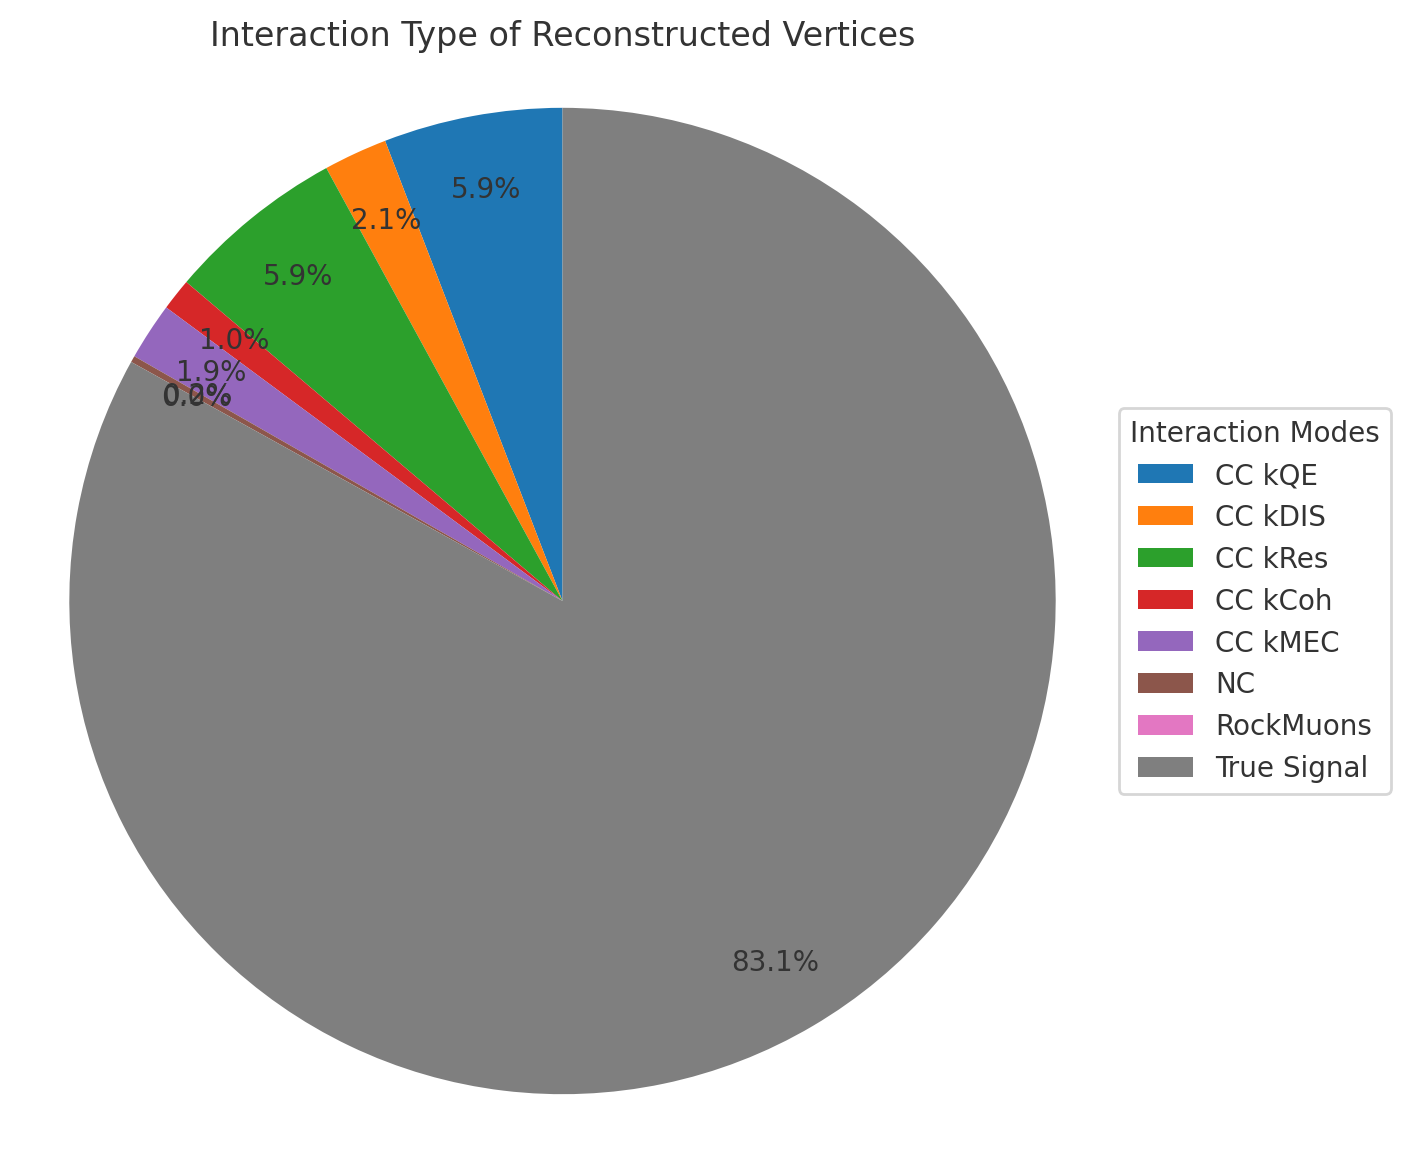

In [76]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode


prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0

# Constants and initialization
tpc_dist_qe=5

ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
CurrentMode = {'NC': 0, 'RockMuons': 2}
scattering_counters = {mode: 0 for mode in ScatteringMode.values()}
current_counters = {mode: 0 for mode in CurrentMode.values()}
insignal_counters = {mode: 0 for mode in ScatteringMode.values()}

# Initialize counters and main loop
num_interactions, num_vertices, count_match_FV, num_match_signal = 0, 0, 0, 0
filtered_data = []

ixn_dict={'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
          'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[]}

#store track length and distance to vtx  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

count_dif_tpc =0
p_count_dif_tpc =0


#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'pdgs':[],
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

wrong_dic ={
    'file_number':[],
    'event_number':[],
    'ixn_number':[],
    'true_ixn_number':[],
    'rec.meta.nd_lar.event':[],
    'mode':[],
    'cc':[]
} 


sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'start':[],
    'end':[]
}

sec_protons=0


for ev in range(len(df)):
    ev_data = df.iloc[ev]
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe,2, QE=True)
    reco_vertices = reco_neutrino_signal(ev_data, ev, xbound, ybound, zbound, tpc_dist_qe, mode='mx2',QE=True)
    match_vertices_signal = np.zeros_like(reco_vertices, dtype=bool)  
    #count number of vertices and interactions 
    num_vertices += np.sum(reco_vertices)
    num_interactions += np.sum(true_interactions)

    for vtx_index, value in enumerate(reco_vertices): 
        if value:  
            match, best_match_idx, match_vertices_signal = matching(ev_data, vtx_index, true_interactions, match_vertices_signal)
            if match: 
                #scan over particles of the event 
                count_match_FV += 1
                filtered_data.append(ev_data)
                #count type of interaction reconstructed in signal 
                insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                ixn_dict['file_number'].append(ev_data['file_number'])
                ixn_dict['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                ixn_dict['ixn_number'].append(vtx_index)
                ixn_dict['true_ixn_number'].append(best_match_idx)
                ixn_dict['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                ixn_dict['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
                ixn_dict['match'].append(1)
                ixn_dict['nprim'].append(ev_data['rec.mc.nu.nprim'][best_match_idx])
                ixn_dict['nsec'].append(ev_data['rec.mc.nu.nsec'][best_match_idx])
                ixn_dict['nproton'].append(ev_data['rec.mc.nu.nproton'][best_match_idx])
                ixn_dict['nneutron'].append(ev_data['rec.mc.nu.nneutron'][best_match_idx])
                ixn_dict['npip'].append(ev_data['rec.mc.nu.npip'][best_match_idx])
                ixn_dict['npim'].append(ev_data['rec.mc.nu.npim'][best_match_idx])
                ixn_dict['npi0'].append(ev_data['rec.mc.nu.npi0'][best_match_idx])

                # #if the interaction has a match, then use it 
                # true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                # reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                # # for each vertex, scan over the particles
                # reco_dic = part_scanner(ev_data,reco_data,vtx_index)
                # num_recoprotons = len(reco_dic['best_match_type'])
                # for index in range(num_recoprotons):
                #     bm_ixn=reco_dic['best_match_ixn'][index]
                #     bm_type=reco_dic['best_match_type'][index]
                #     bm_idx=reco_dic['best_match_idx'][index]
                #     parent_id = reco_dic['parent_id'][index]

                #     #this are reco values of the reconstructed protons
                #     reco_energy=reco_dic['energy'][index]
                #     track_length=reco_dic['length'][index]
                #     vtx_distance=reco_dic['distance'][index]
                #     start_point=reco_dic['start'][index]
                #     end_point=reco_dic['vtx_pos1'][index]

                #     #get the true info from best match 
                #     bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                #     bm_dic = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                #     reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                #     reco_proton_dic['best_match_type'].append(bm_dic['type'])
                #     #these are the true info from the best match
                #     reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                #     reco_proton_dic['best_match_length'].append(bm_dic['length'])
                #     reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                #     reco_proton_dic['vtx_t'].append(bm_ixn)
                #     reco_proton_dic['parent_id'].append(parent_id)
                #     #reco info
                #     reco_proton_dic['reco_energy'].append(reco_energy)
                #     reco_proton_dic['reco_length'].append(track_length)
                #     reco_proton_dic['reco_distance'].append(vtx_distance)
                #     reco_proton_dic['vtx_r'].append(vtx_index)
                #     reco_proton_dic['ev'].append(ev)
                    

                #     if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                #         sec_protons+=1
                #         neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                #         #print(bm_ixn, parent_id)

                    

                #         if neutron_induced:
                #             # Example point
                      
                #             tpc_start = find_box(start_point[2], start_point[0], x_boundaries, box_mapping)
                #             tpc_end = find_box(end_point[2], end_point[0], x_boundaries, box_mapping)
                #             if (tpc_end != None) and (tpc_start != None) and (tpc_start != tpc_end):
                #                 count_dif_tpc += 1
            
                #             sample_dic['reco_length'].append(track_length)
                #             sample_dic['reco_distance'].append(vtx_distance)
                #             sample_dic['reco_energy'].append(reco_energy)
                #             sample_dic['best_match_energy'].append(bm_dic['energy'])
                #             sample_dic['best_match_length'].append(bm_dic['length'])
                #             sample_dic['best_match_distance'].append(bm_dic['distance'])

                        
  
                #     else:
                #         tpc_start = find_box(start_point[2], start_point[0], x_boundaries, box_mapping)
                #         tpc_end = find_box(end_point[2], end_point[0], x_boundaries, box_mapping)
                #         if (tpc_end != None) and (tpc_start != None) and (tpc_start != tpc_end):
                #             p_count_dif_tpc += 1

                # sec_dic['track_neutron'] = []
                # prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
                # sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
                # neutron_particle_count = Counter(sec_dic['track_neutron'])
                # for count in neutron_particle_count.values():
                #     if count > 1: multi += 1
                #     elif count == 1: single += 1
                    
            elif best_match_idx is not None:
                scattering_counters, current_counters = type_interaction(
                    ev_data, scattering_counters, ScatteringMode, current_counters, CurrentMode, best_match_idx
                )
                
                wrong_dic['file_number'].append(ev_data['file_number'])
                wrong_dic['event_number'].append(ev_data['rec.meta.nd_lar.event'])
                wrong_dic['ixn_number'].append(vtx_index)
                wrong_dic['true_ixn_number'].append(best_match_idx)
                wrong_dic['cc'].append(ev_data['rec.mc.nu.iscc'][best_match_idx])
                wrong_dic['mode'].append(ev_data['rec.mc.nu.mode'][best_match_idx])
    # num_match_signal +=np.sum(match_vertices_signal)
    # pdg_counter = Counter(sec_dic['pdg'])

           #if the interaction has a match, then use it 
            true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
            reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
            # for each vertex, scan over the particles
            reco_dic = part_scanner(ev_data,reco_data,vtx_index)
            num_recoprotons = len(reco_dic['best_match_type'])
            for index in range(num_recoprotons):
                bm_ixn=reco_dic['best_match_ixn'][index]
                bm_type=reco_dic['best_match_type'][index]
                bm_idx=reco_dic['best_match_idx'][index]
                parent_id = reco_dic['parent_id'][index]

                #this are reco values of the reconstructed protons
                reco_energy=reco_dic['energy'][index]
                track_length=reco_dic['length'][index]
                vtx_distance=reco_dic['distance'][index]
                start_point=reco_dic['start'][index]
                end_point=reco_dic['vtx_pos1'][index]

                #get the true info from best match 
                bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                bm_dic = get_bm_truth_data(bm_truth_data,bm_type, bm_idx)

                reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                reco_proton_dic['best_match_type'].append(bm_dic['type'])
                #these are the true info from the best match
                reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                reco_proton_dic['best_match_length'].append(bm_dic['length'])
                reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                reco_proton_dic['vtx_t'].append(bm_ixn)
                reco_proton_dic['parent_id'].append(parent_id)
                #reco info
                reco_proton_dic['reco_energy'].append(reco_energy)
                reco_proton_dic['reco_length'].append(track_length)
                reco_proton_dic['reco_distance'].append(vtx_distance)
                reco_proton_dic['vtx_r'].append(vtx_index)
                reco_proton_dic['ev'].append(ev)
                

                if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                    sec_protons+=1
                    neutron_induced=was_neutron_induced(ev_data, bm_ixn, parent_id)
                    #print(bm_ixn, parent_id)

                

                    if neutron_induced:
                        # Example point
                    
                        tpc_start = find_box(start_point[2], start_point[0], x_boundaries, box_mapping)
                        tpc_end = find_box(end_point[2], end_point[0], x_boundaries, box_mapping)
                        if (tpc_end != None) and (tpc_start != None) and (tpc_start != tpc_end):
                            count_dif_tpc += 1
        
                        sample_dic['reco_length'].append(track_length)
                        sample_dic['reco_distance'].append(vtx_distance)
                        sample_dic['reco_energy'].append(reco_energy)
                        sample_dic['best_match_energy'].append(bm_dic['energy'])
                        sample_dic['best_match_length'].append(bm_dic['length'])
                        sample_dic['best_match_distance'].append(bm_dic['distance'])

                    

                else:
                    tpc_start = find_box(start_point[2], start_point[0], x_boundaries, box_mapping)
                    tpc_end = find_box(end_point[2], end_point[0], x_boundaries, box_mapping)
                    if (tpc_end != None) and (tpc_start != None) and (tpc_start != tpc_end):
                        p_count_dif_tpc += 1

            sec_dic['track_neutron'] = []
            prim_dic = particles_inx(ev_data, best_match_idx, 'prim', prim_dic)
            sec_dic = particles_inx(ev_data, best_match_idx, 'sec', sec_dic)
            neutron_particle_count = Counter(sec_dic['track_neutron'])
            for count in neutron_particle_count.values():
                if count > 1: multi += 1
                elif count == 1: single += 1
    num_match_signal +=np.sum(match_vertices_signal)
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

print(f'There are {num_vertices} reconstructed vertices.')
print(f'There are {count_match_FV} reco vertices matching true interaction signal.')
print(f'There are {num_interactions} true interactions')
e, p = efficiency_purity(count_match_FV, num_vertices, num_interactions)
display_summary(e, p, scattering_counters, current_counters, insignal_counters)
plot_interactions(scattering_counters, current_counters, count_match_FV, ScatteringMode, CurrentMode)
df_out = pd.DataFrame.from_dict(ixn_dict)
df_out.to_csv('MR6_QE_like_ixn.csv',index=False)

In [ ]:


ScatteringMode = [ 1,3,4,5,10] 


file=np.array(wrong_dic['file_number'])
mode=np.array(wrong_dic['mode'])
int=np.array(wrong_dic['ixn_number'])
event=np.array(wrong_dic['event_number'])
true_vtx = np.array(wrong_dic['true_ixn_number'])

file_dis= file[mode==3]
int_dis = int[mode==3]
event_dis= event[mode==3]
int_dis = int[mode==3]
true_vtx_dis=true_vtx[mode==3]

In [112]:
data = {
    'File': file_dis,
    'Interaction': int_dis,
    'Event': event_dis,
    'True Vertex': true_vtx_dis
}
df = pd.DataFrame(data)

# Saving to CSV
df.to_csv('scattering_mode_filtered.csv', index=False)

print("CSV file 'scattering_mode_filtered.csv' has been generated.")

df

CSV file 'scattering_mode_filtered.csv' has been generated.


,File,Interaction,Event,True Vertex
0,152.0,1,140,0
1,165.0,0,127,0
2,167.0,0,140,0
3,173.0,1,33,1
4,267.0,0,78,0
5,374.0,1,36,1
6,594.0,0,87,0
7,606.0,0,168,0
8,711.0,1,1,1
9,800.0,0,40,0


In [113]:
file = np.array(wrong_dic['file_number'])
mode = np.array(wrong_dic['mode'])
intx = np.array(wrong_dic['ixn_number'])
event = np.array(wrong_dic['event_number'])
true_vtx = np.array(wrong_dic['true_ixn_number'])

# Scattering modes to process
scattering_modes = [1, 3, 4, 5, 10]

# Loop through each mode and save corresponding data to CSV
for scattering_mode in scattering_modes:
    file_dis = file[mode == scattering_mode]
    int_dis = intx[mode == scattering_mode]
    event_dis = event[mode == scattering_mode]
    true_vtx_dis = true_vtx[mode == scattering_mode]

    # Creating a DataFrame
    data = {
        'File': file_dis,
        'Interaction': int_dis,
        'Event': event_dis,
        'True Vertex': true_vtx_dis
    }
    df = pd.DataFrame(data)

    # Saving to CSV
    filename = f'scattering_mode_{scattering_mode}.csv'
    df.to_csv(filename, index=False)

    print(f"CSV file '{filename}' has been generated.")


CSV file 'scattering_mode_1.csv' has been generated.
CSV file 'scattering_mode_3.csv' has been generated.
CSV file 'scattering_mode_4.csv' has been generated.
CSV file 'scattering_mode_5.csv' has been generated.
CSV file 'scattering_mode_10.csv' has been generated.


In [117]:

file = np.array(wrong_dic['file_number'])
mode = np.array(wrong_dic['mode'])
intx = np.array(wrong_dic['ixn_number'])
event = np.array(wrong_dic['event_number'])
true_vtx = np.array(wrong_dic['true_ixn_number'])

# Scattering modes to process
scattering_modes = [1, 3, 4, 5, 10]

# Collecting data for all scattering modes
all_data = []

for scattering_mode in scattering_modes:
    file_dis = file[mode == scattering_mode]
    int_dis = intx[mode == scattering_mode]
    event_dis = event[mode == scattering_mode]
    true_vtx_dis = true_vtx[mode == scattering_mode]

    # Appending data with scattering mode identifier
    data = {
        'Scattering Mode': [scattering_mode] * len(file_dis),
        'File': file_dis,
        'Interaction': int_dis,
        'Event': event_dis,
        'True Vertex': true_vtx_dis
    }
    df = pd.DataFrame(data)
    all_data.append(df)

# Combining all data into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Saving to a single CSV
combined_df.to_csv('scattering_modes_combined.csv', index=False)

print("CSV file 'scattering_modes_combined.csv' has been generated with all scattering modes.")

combined_df

CSV file 'scattering_modes_combined.csv' has been generated with all scattering modes.


,Scattering Mode,File,Interaction,Event,True Vertex
0,1,39.0,3,79,2
1,1,84.0,2,63,2
2,1,169.0,0,178,0
3,1,174.0,1,78,1
4,1,249.0,0,126,0
...,...,...,...,...,...
76,10,331.0,2,168,1
77,10,507.0,3,70,2
78,10,772.0,3,34,1
79,10,975.0,0,118,0


In [49]:
ScatteringMode = {"All": None,"kQE": 1, "kDIS": 3, "kRes": 4, "kCoh": 5, "kMEC": 10}
results = [] # List to store the results for each mode

#for key, value in ScatteringMode.items():
    
prim_dic = {'E': []}
sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
multi = 0
single = 0
c=0
for ev in range(len(df)):
    ev_data = df.iloc[ev]
    #true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist, value)
    true_interactions = true_neutrino_signal(ev_data, pdg_tab, xbound, ybound, zbound, tpc_dist_qe,2, QE=False)
    for inx, interaction_value in enumerate(true_interactions):
        if interaction_value:
            c+=1
            sec_dic['track_neutron'] = []
            prim_dic = particles_inx(ev_data, inx, 'prim', prim_dic)
            sec_dic = particles_inx(ev_data, inx, 'sec', sec_dic)
            neutron_particle_count = Counter(sec_dic['track_neutron'])
            for count in neutron_particle_count.values():
                if count > 1: multi += 1
                elif count == 1: single += 1
    pdg_counter = Counter(sec_dic['pdg'])

results.append({
    'Neutrons': len(prim_dic['E']),
    'Secondary': len(sec_dic['E']),
    'SecProton': pdg_counter[pdg_tab.proton],
    'SecNeutron': pdg_counter[pdg_tab.neutron],
    'SecPhoton': pdg_counter[pdg_tab.photon],
    'Single': single,
    'Multi': multi
})
# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)
print(results_df)
Counter(sec_dic['pdg'])

   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0     31379       5386       3219        1121        271    2241   1043


Counter({2212: 3219,
         2112: 1121,
         22: 271,
         111: 216,
         -211: 192,
         1000010020: 179,
         211: 84,
         11: 80,
         1000010030: 13,
         1000020040: 5,
         1000010040: 2,
         -11: 2,
         3112: 1,
         3122: 1})

: 

In [38]:
c

2850

In [71]:
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

#case for sec = 1 prim =1

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0             11290                 6322             1030    0.56       0.512
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0     19552       3356       2013         695        162    1426    649
None


In [53]:
truee= 3219 
1030/truee

0.3199751475613545

In [39]:
count_dif_tpc, p_count_dif_tpc
2496/10006, count_dif_tpc/946

p_count_dif_tpc, count_dif_tpc


(36, 34)

In [41]:
#exclusive false
# 
reco_results =[]
proton_purity = round(sec_protons/len(reco_proton_dic['best_match_pdg']),3)
proton_efficiency = round(len(sample_dic['reco_length'])/results_df['SecProton'][0],3)
reco_results.append({
    'reco_sec_protons': len(reco_proton_dic['best_match_pdg']),
    'matched_sec_protons': sec_protons,
    'neutron_induced': len(sample_dic['reco_distance']),
    'purity': proton_purity,
    'efficiency':proton_efficiency 
})
# Convert the results list to a DataFrame
reco_results_df = pd.DataFrame(reco_results)
print(reco_results_df)
print(print(results_df))

   reco_sec_protons  matched_sec_protons  neutron_induced  purity  efficiency
0               968                  423              156   0.437       0.619
   Neutrons  Secondary  SecProton  SecNeutron  SecPhoton  Single  Multi
0      2017        417        252         109         14     194     87
None


Counter({2212: 9062, 211: 565, 1000010020: 283, 22: 156, 11: 83, 1000010030: 26, 321: 10, 13: 7, 2112: 4, 1000020040: 2, 3112: 2, 1000010040: 1, 1000020030: 1})
total protons:9062, total particles: 10202
{'prim_protons': 2842, 'sec_protons': 5202, 'pions': 565, 'others': 575, 'neutron_induced': 1018}


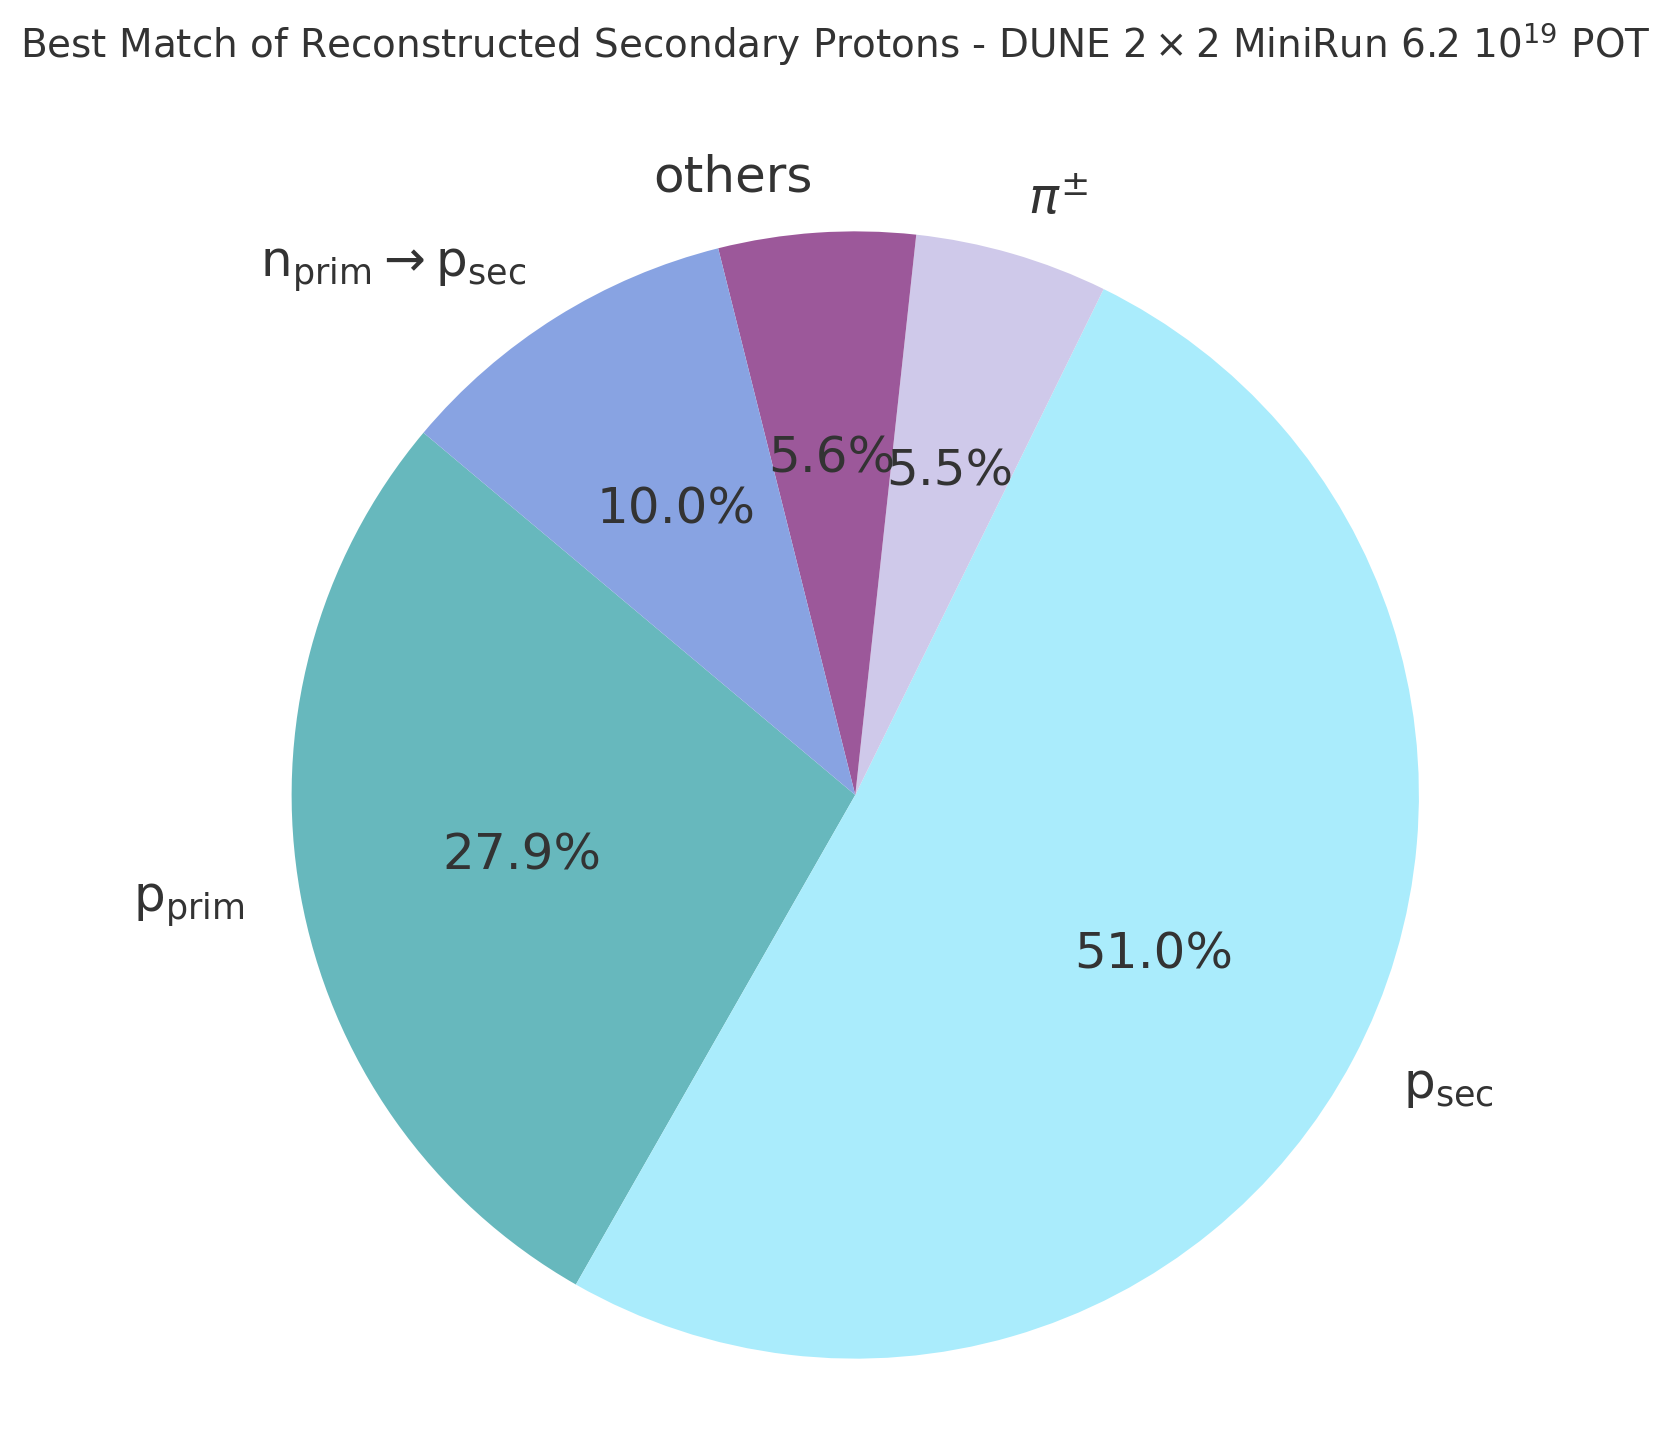

In [62]:

from collections import Counter
pdgs = np.array(reco_proton_dic['best_match_pdg'])
C = Counter(np.abs(pdgs))

blue_p='#9c589a'
purple_p='#67b8bd'
pink_p='#cfc9ea'
yellow_p ='#88A3E2'
green_p='#AAECFC'

pdgs = np.array(reco_proton_dic['best_match_pdg'])
tipo = np.array(reco_proton_dic['best_match_type'])
bmlength = np.array(reco_proton_dic['best_match_length'])
bmdistance = np.array(reco_proton_dic['best_match_distance'])
recolength = np.array(reco_proton_dic['reco_length'])
recodistance = np.array(reco_proton_dic['reco_distance'])

# Define masks
bm_prim_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 1)
bm_sec_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 3)

# Count occurrences
C = Counter(np.abs(pdgs))
np.unique(pdgs), len(pdgs)
print(C)
total_protons = C[2212]
total=len(pdgs)
print(f'total protons:{total_protons}, total particles: {total}')
# Add counts for specific particles
C['2212_prim'] = np.sum(bm_prim_protons_mask)
C['2212_sec'] = np.sum(bm_sec_protons_mask) - len(sample_dic['reco_energy'])
C['2212_n_ind'] = len(sample_dic['reco_energy'])

# Initialize dictionary
dic_results = {
   'prim_protons': 0,
   'sec_protons': 0,
   'pions': 0,
   'others': 0,
   'neutron_induced':0
}

# Populate dictionary with counts
for key, value in C.items():
   if key == '2212_prim':
      dic_results['prim_protons'] = np.sum(bm_prim_protons_mask)
   elif key == '2212_sec':
      dic_results['sec_protons'] = np.sum(bm_sec_protons_mask) - len(sample_dic['reco_energy'])
   elif key == 211:
      dic_results['pions'] = value
   elif key== 2212: continue
 #     dic_results['all_protons'] = value
   elif key == '2212_n_ind':
      dic_results['neutron_induced'] = len(sample_dic['reco_energy'])
   else: 
      dic_results['others'] += value  # Use += to add to the count

print(dic_results)

labels = [r'$\text{p}_\text{prim}$',r'$\text{p}_\text{sec}$',r'$\pi^{\pm}$','others', r'$\text{n}_\text{prim}\rightarrow \text{p}_\text{sec}$']
sizes = dic_results.values()
colors = plt.cm.Paired(range(len(labels)))  # Color map for distinct colors

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=[  purple_p, green_p, pink_p,blue_p, yellow_p] , autopct='%1.1f%%', startangle=140,textprops={'fontsize': 18})
plt.suptitle(r'Best Match of Reconstructed Secondary Protons - DUNE $2\times 2$ MiniRun 6.2 $ 10^{19}$ POT ', fontsize = '14')
#plt.suptitle('Best match of reconstructed secondary protons', fontsize=10)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
#plt.legend(fontsize = 7,loc='upper right')

plt.show()

In [63]:
bmlentrack = {}
bmdistancetrack ={}

recolentrack = {}
recodistancetrack ={}

percents={}
#dic_results


pdgs = np.array(reco_proton_dic['best_match_pdg'])
tipo = np.array(reco_proton_dic['best_match_type'])
bmlength = np.array(reco_proton_dic['best_match_length'])
bmdistance = np.array(reco_proton_dic['best_match_distance'])
recolength = np.array(reco_proton_dic['reco_length'])
recodistance = np.array(reco_proton_dic['reco_distance'])

# Define masks
bm_prim_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 1)
bm_sec_protons_mask = (pdgs == pdg_tab.proton) & (tipo == 3)


bmlentrack = {}
bmdistancetrack ={}

recolentrack = {}
recodistancetrack ={}

percents={}
#dic_results

for i,value in dic_results.items():
    if i =='prim_protons':
        bmlentrack[i] = bmlength[bm_prim_protons_mask]
        bmdistancetrack[i] = bmdistance[bm_prim_protons_mask]
        recolentrack[i] = recolength[bm_prim_protons_mask]
        recodistancetrack[i] = recodistance[bm_prim_protons_mask]
        percents[i] = (value/total)*100
    elif i == 'pions':
        # Use bitwise OR for element-wise logical operations
        bmlentrack[i] = bmlength[(np.abs(pdgs) == 211)]
        bmdistancetrack[i] = bmdistance[((np.abs(pdgs) == 211))]
        recolentrack[i] = recolength[(np.abs(pdgs) == 211)]
        recodistancetrack[i] = recodistance[((np.abs(pdgs) == 211))]
        percents[i] = (value/total)*100
    elif i =='sec_protons':
        bmlentrack[i] = bmlength[bm_sec_protons_mask]
        bmdistancetrack[i] = bmdistance[bm_sec_protons_mask]
        recolentrack[i] = recolength[bm_sec_protons_mask]
        recodistancetrack[i] = recodistance[bm_sec_protons_mask]
        percents[i] = (value/total)*100
    elif i == 'muons':
        bmlentrack[i] = bmlength[(np.abs(pdgs) == 13)]
        bmdistancetrack[i] = bmdistance[((np.abs(pdgs) == 13))]
        recolentrack[i] = recolength[(np.abs(pdgs) == 13)]
        recodistancetrack[i] = recodistance[((np.abs(pdgs) == 13))]
        percents[i] = (value/total)*100
    else:
        bmlentrack['others'] = bmlength[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        bmdistancetrack['others'] = bmdistance[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        recolentrack['others'] = recolength[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        recodistancetrack['others'] = recodistance[(np.abs(pdgs) == 321) | (np.abs(pdgs) == 3222)]
        percents['others'] = (value/total)*100


labels=[]
for key, value in percents.items():
    if key=='others':continue
    labels.append(f'{key} ({value:.2f}%)')
labels.append(f'others ({percents['others']:.2f}%)')

print(labels)
print(percents)



['prim_protons (27.86%)', 'sec_protons (50.99%)', 'pions (5.54%)', 'others (9.98%)']
{'prim_protons': 27.857282885708685, 'sec_protons': 50.99000196039992, 'pions': 5.538129778474809, 'others': 9.978435600862575}


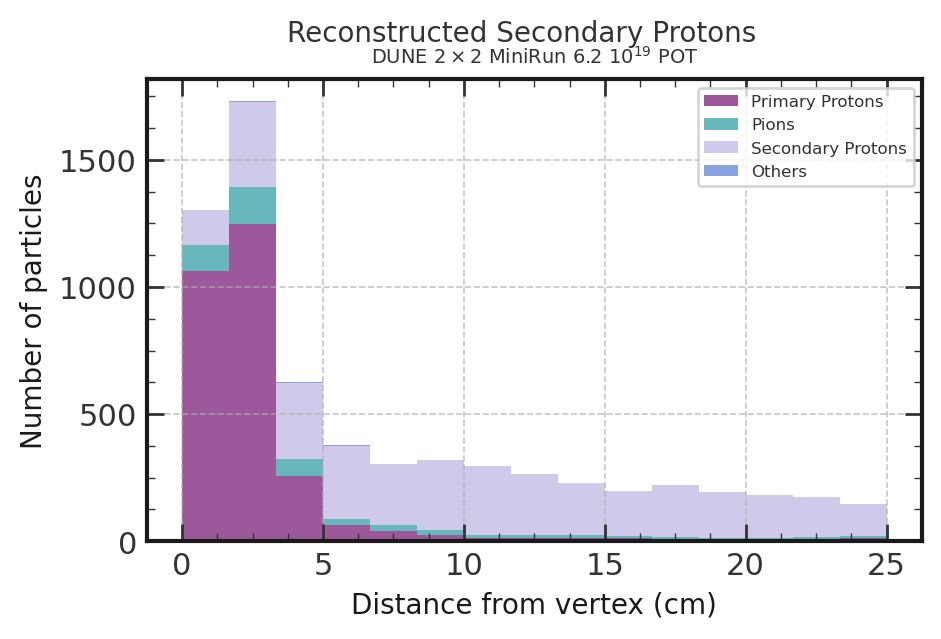

In [64]:
import matplotlib.pyplot as plt

# Define your color hex codes
blue_p   = '#9c589a'
purple_p = '#67b8bd'
pink_p   = '#cfc9ea'
yellow_p = '#88A3E2'
green_p  = '#AAECFC'  # Not used in this example

# Create a list of your datasets
data_list = [
    recodistancetrack['prim_protons'],
    recodistancetrack['pions'],
    recodistancetrack['sec_protons'],
    recodistancetrack['others']
]

# Create a list of labels corresponding to each dataset
labels = ["Primary Protons", "Pions", "Secondary Protons", "Others"]

# Create a list of colors to use (length must match number of datasets)
colors = [blue_p, purple_p, pink_p, yellow_p]

# Plot the stacked histogram
plt.hist(
    data_list,
    bins=15,
    stacked=True,
    range=[0, 25],
    label=labels,
    color=colors  # pass the list of colors
)

plt.xlabel('Distance from vertex (cm)', fontsize=10)
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize=7)
plt.suptitle('Reconstructed Secondary Protons', fontsize=10)
plt.legend(loc='upper right', fontsize=6)
plt.show()


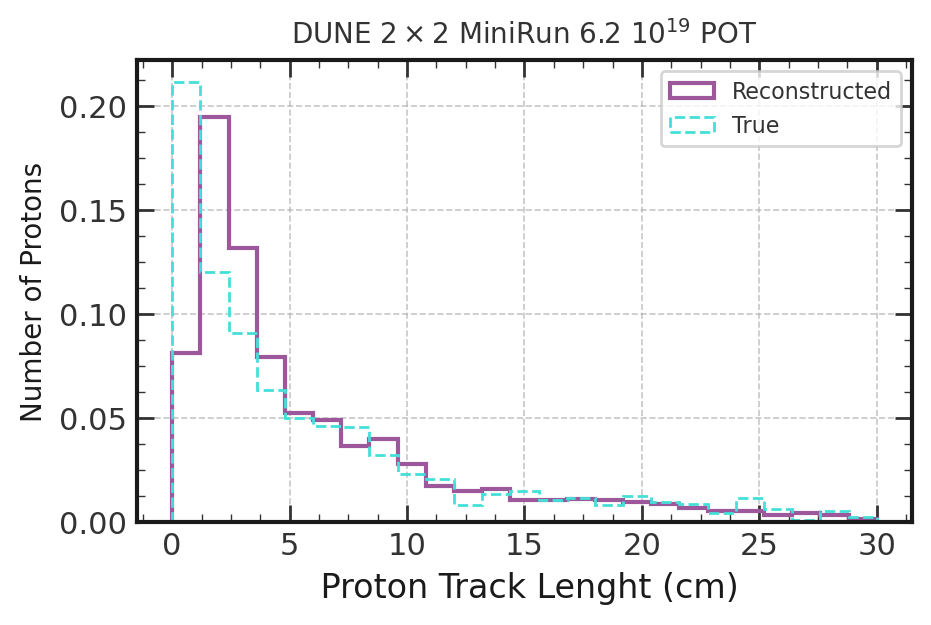

In [65]:
# sample_dic['reco_length'].append(track_length)
# sample_dic['reco_distance'].append(track_length)
# sample_dic['reco_energy'].append(reco_energy)
# sample_dic['best_match_energy'].append(best_match_energy)
# sample_dic['best_match_distance'].append(vtx_distance_truth)
# sample_dic['best_match_length'].append(track_length_truth) 
l= [m/1000 for m in sample_dic['best_match_length']]

plt.hist(sample_dic['reco_length'],bins=25,histtype='step', range=[0,30], color=blue_p, linewidth=1.5,density=True,label=r'Reconstructed')
plt.hist(sample_dic['best_match_length'],bins=25,histtype='step',range=[0,30], color='#43dfd8',linestyle='--', density=True,linewidth=1,label=r'True')
#plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
plt.xlabel(' Proton Track Lenght (cm)')
plt.ylabel('Number of Protons', fontsize='10')
plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

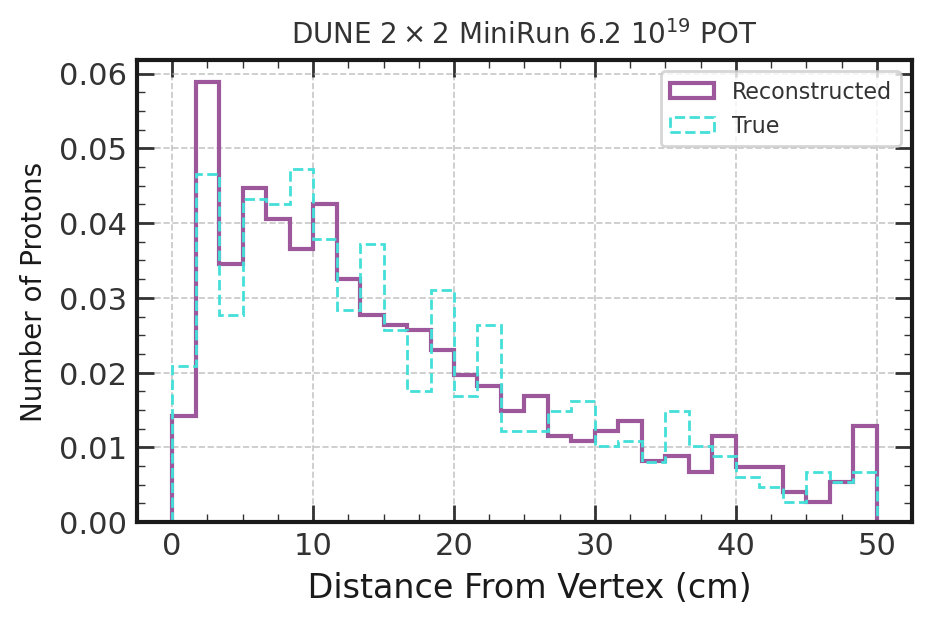

In [66]:
case1rd=sample_dic['reco_distance']
case1td=sample_dic['best_match_distance']
plt.hist(case1rd,bins=30,histtype='step', range=[0,50], color=blue_p, linewidth=1.5,density=True,label=r'Reconstructed')
plt.hist(case1td,bins=30,histtype='step',range=[0,50], color='#43dfd8',linestyle='--', density=True,linewidth=1,label=r'True')
#plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
plt.xlabel(' Distance From Vertex (cm)')
plt.ylabel('Number of Protons', fontsize='10')
plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '10')
plt.legend(loc='upper right', fontsize='8') 
plt.show()

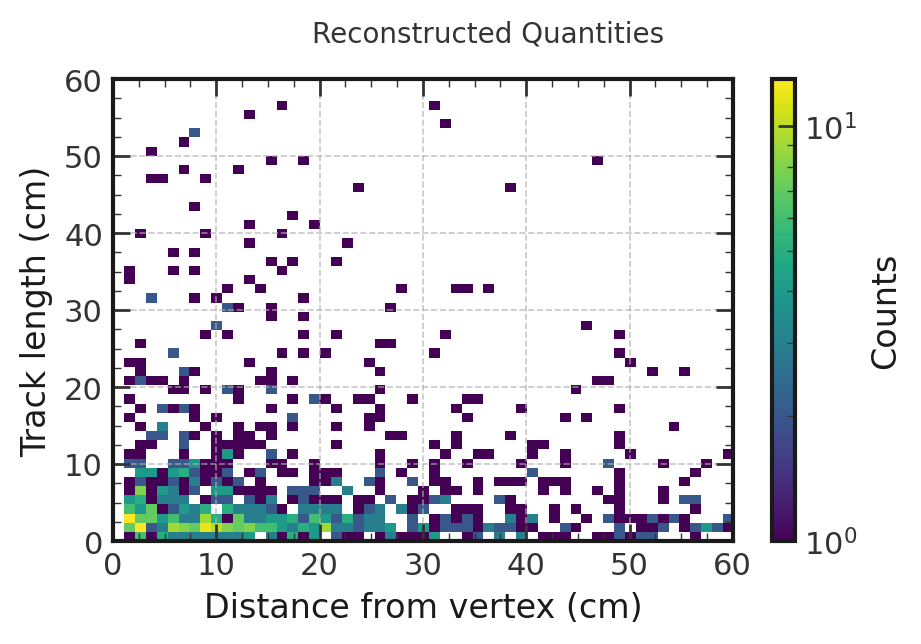

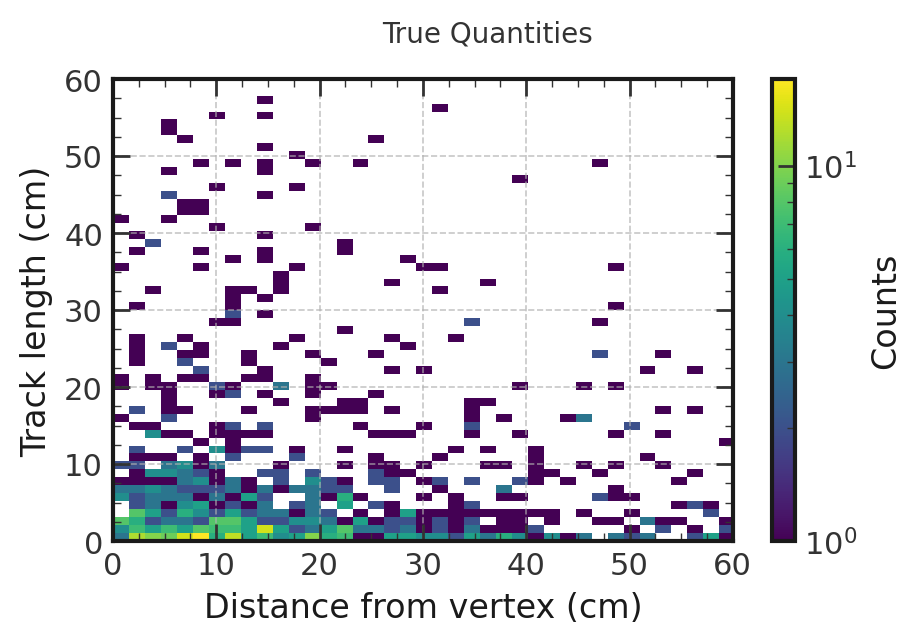

In [67]:
import matplotlib.colors as mcolors  # Importing the correct module for colors

plt.hist2d(sample_dic['reco_distance'],sample_dic['reco_length'],  bins=105, norm=mcolors.LogNorm(), cmap='viridis')
# plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 60)
plt.ylim(0,60)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
#plt.title(r'DUNE $2\times 2$ MiniRun 6.2, $10^{19}$ POT', fontsize = '7')
plt.suptitle(r'Reconstructed Quantities', fontsize = '10')
#plt.legend(fontsize='8')
plt.show()

plt.hist2d(sample_dic['best_match_distance'],sample_dic['best_match_length'],  bins=500, norm=mcolors.LogNorm(), cmap='viridis')
# plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
#plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '7')
plt.suptitle(r'True Quantities', fontsize = '10')
#plt.legend(fontsize='8')
plt.show()



(-100.0, 100.0)

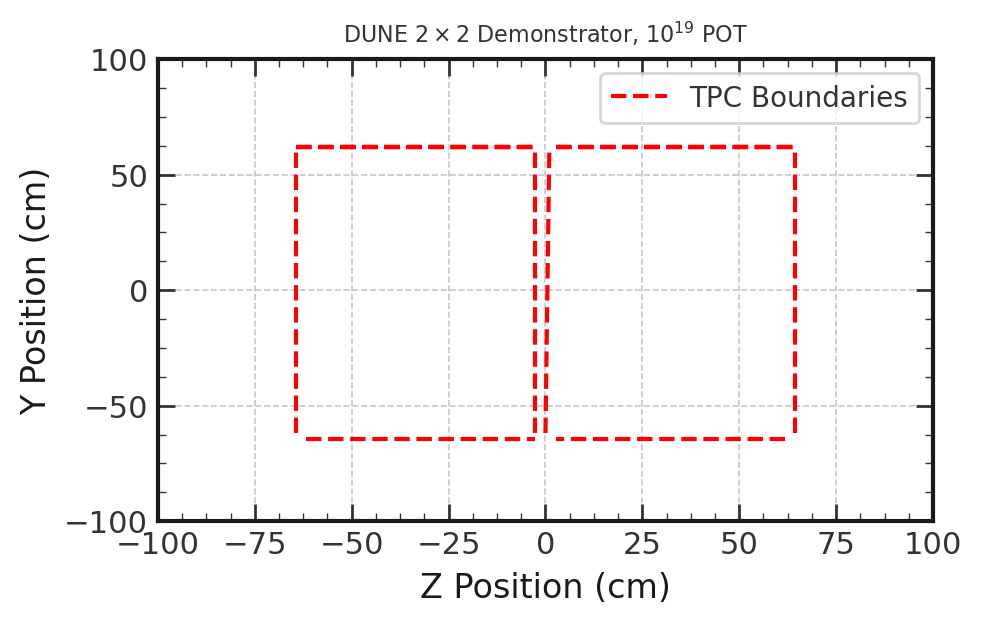

In [68]:
#plt.hist2d(vertices_z, vertices_y, bins=100, cmap='Blues', cmin=0.01)
import matplotlib.colors as mcolors  # Importing the correct module for colors
import plotly.graph_objects as go

x_boundaries = np.array([-63.931, -3.069, 3.069, 63.931])
y_boundaries = np.array([-61.8543, 61.8543])
z_boundaries = np.array([-64.3163,  -2.6837, 2.6837, 64.3163])

def draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries)/2)):
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = (x_boundaries[i_x * 2] + x_boundaries[i_x * 2 + 1]) * 0.5 * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))

    return traces

def draw_anode_planes(x_boundaries, y_boundaries, z_boundaries, **kwargs):
    
    traces = []
    for i_z in range(int(len(z_boundaries)/2)):
        for i_x in range(int(len(x_boundaries))):           
            z, y = np.meshgrid(np.linspace(z_boundaries[i_z * 2], z_boundaries[i_z * 2 + 1], 2), np.linspace(y_boundaries.min(), y_boundaries.max(),2))
            x = x_boundaries[i_x] * np.ones(z.shape)

            traces.append(go.Surface(x=x, y=y, z=z, **kwargs))
    
    return traces


traces_anode = draw_anode_planes(x_boundaries, y_boundaries, z_boundaries)
traces_cathode = draw_cathode_planes(x_boundaries, y_boundaries, z_boundaries)

for i in range(0,8):
    plt.plot(traces_anode[i]['z'][1], traces_anode[i]['y'][1], 'r--')
#     plt.plot(traces_anode[i]['y'][1], traces_anode[i]['z'][1], 'r--')
plt.plot([-traces_anode[0]['y'][1][1], traces_anode[0]['y'][1][1]],'r--',label='TPC Boundaries')
plt.plot([-64.3163,-64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([64.3163,64.3163 ],[-61.8543,61.8543], 'r--')
plt.plot([-2.6837,-2.6837 ],[-61.8543,61.8543], 'r--')
plt.plot([-61.8543,-2.6837], [-64.3163,-64.3163 ],'r--')
plt.plot([61.8543,2.6837], [-64.3163,-64.3163 ],'r--')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '8')
plt.legend(fontsize='8')
plt.xlabel('Z Position (cm)')
plt.ylabel('Y Position (cm)')
plt.legend()
plt.xlim(-100, 100)
plt.ylim(-100, 100)



Point (10, 20) maps to row 3, column 3
Point (10, 20) is outside the TPC boundaries.


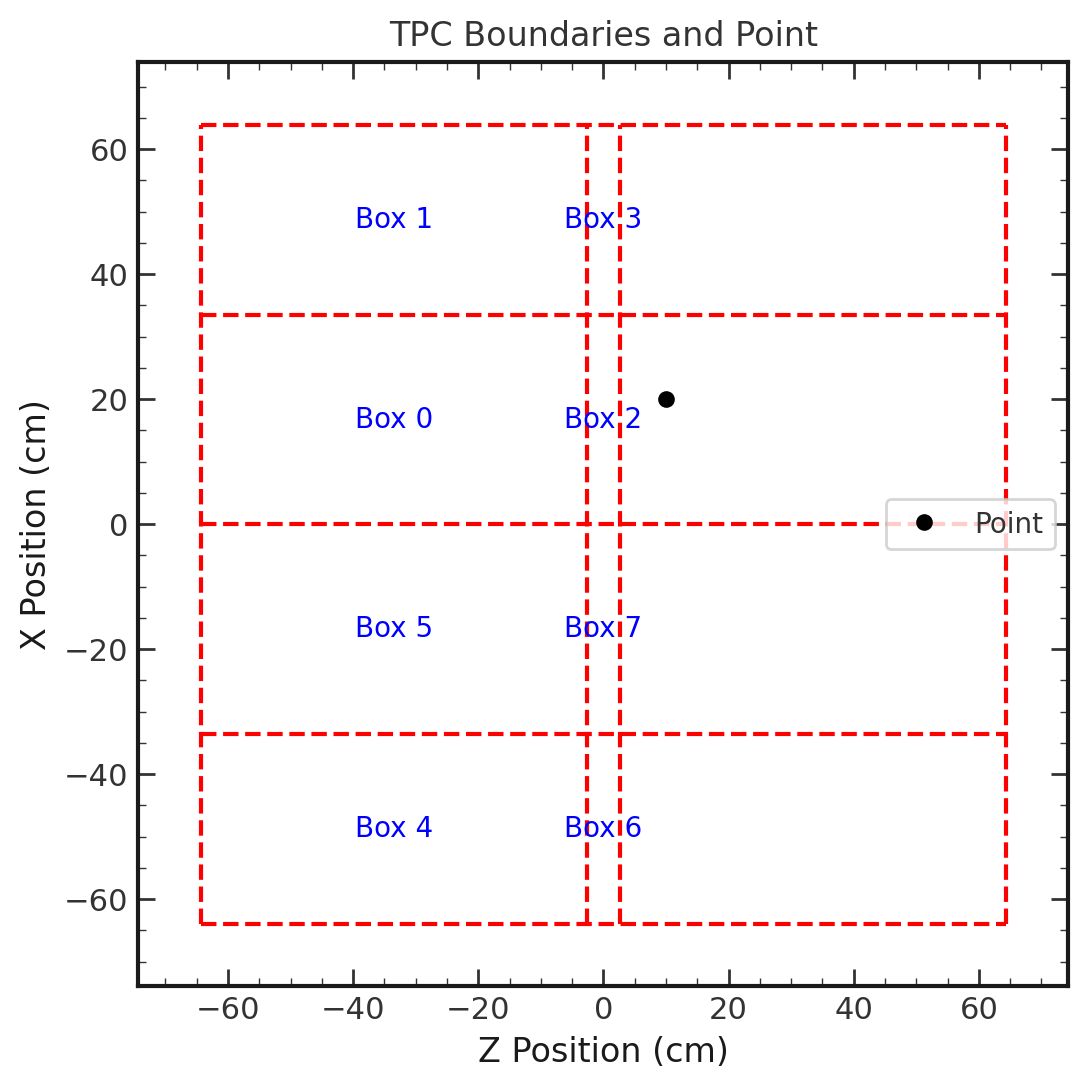

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the boundaries
z_boundaries = np.array([-64.3163, -2.6837, 2.6837, 64.3163])  # Z-axis (horizontal)
x_boundaries = np.array([-63.931, -33.5, 0, 33.5, 63.931])     # X-axis (vertical)

# Define the box mapping
# Each pair (row, col) uniquely maps to a box number from 0 to 7
box_mapping = {
    (1, 1): 4, (2, 1): 5,  # Top-left (module 2 split into two boxes)
    (1, 2): 6, (2, 2): 7,  # Top-right (module 3 split into two boxes)
    (3, 1): 0, (4, 1): 1,  # Bottom-left (module 0 split into two boxes)
    (3, 2): 2, (4, 2): 3   # Bottom-right (module 1 split into two boxes)
}

def find_box(z, x, z_boundaries, x_boundaries, box_mapping):
    """
    Determines which box the point (z, x) falls into.
    """
    box_row, box_col = None, None
    
    # Check which Z-boundary range the point lies in (columns along Z-axis)
    for i in range(len(z_boundaries) - 1):
        if z_boundaries[i] <= z <= z_boundaries[i + 1]:  # Include upper boundary
            box_col = i + 1  # Adjust to 1-based index
            break
    
    # Check which X-boundary range the point lies in (rows along X-axis)
    for j in range(len(x_boundaries) - 1):
        if x_boundaries[j] <= x <= x_boundaries[j + 1]:  # Include upper boundary
            box_row = j + 1  # Adjust to 1-based index
            break
    
    if box_row is not None and box_col is not None:
        # Debugging outputs to verify mapping
        print(f"Point ({z}, {x}) maps to row {box_row}, column {box_col}")
        return box_mapping.get((box_row, box_col), None)
    else:
        return None  # Point is outside all boxes


def plot_boundaries_and_point(z_boundaries, x_boundaries, point):
    """
    Plots the TPC boundaries and the point on the graph.
    
    Parameters:
        z_boundaries (np.array): Array of z boundaries (horizontal axis).
        x_boundaries (np.array): Array of x boundaries (vertical axis).
        point (tuple): Coordinates of the point (z, x).
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw boundaries
    for z in z_boundaries:
        ax.plot([z, z], [x_boundaries.min(), x_boundaries.max()], 'r--')  # Vertical lines (Z boundaries)
    for x in x_boundaries:
        ax.plot([z_boundaries.min(), z_boundaries.max()], [x, x], 'r--')  # Horizontal lines (X boundaries)
    
    # Add labels for boxes
    for row in range(1, len(x_boundaries)):
        for col in range(1, len(z_boundaries)):
            box = box_mapping.get((row, col), None)
            if box is not None:
                center_z = (z_boundaries[col - 1] + z_boundaries[col]) / 2
                center_x = (x_boundaries[row - 1] + x_boundaries[row]) / 2
                ax.text(center_z, center_x, f"Box {box}", color="blue", ha="center", va="center", fontsize=10)
    
    # Plot the point
    ax.plot(point[0], point[1], 'ko', label="Point")
    ax.legend()
    
    # Set axis limits and labels
    ax.set_xlim(z_boundaries.min() - 10, z_boundaries.max() + 10)
    ax.set_ylim(x_boundaries.min() - 10, x_boundaries.max() + 10)
    ax.set_xlabel("Z Position (cm)")
    ax.set_ylabel("X Position (cm)")
    ax.set_title("TPC Boundaries and Point")
    plt.grid()
    plt.show()

# Example point
point = (10, 20)  # Replace with your (z, x) point
box = find_box(point[0], point[1], z_boundaries, x_boundaries, box_mapping)

if box is not None:
    print(f"Point {point} lies in box {box}.")
else:
    print(f"Point {point} is outside the TPC boundaries.")

# Plot the boundaries and the point
plot_boundaries_and_point(z_boundaries, x_boundaries, point)


Point (z=10, x=20.0) => row=3, col=2
Point (10, 20.0) lies in box 2.


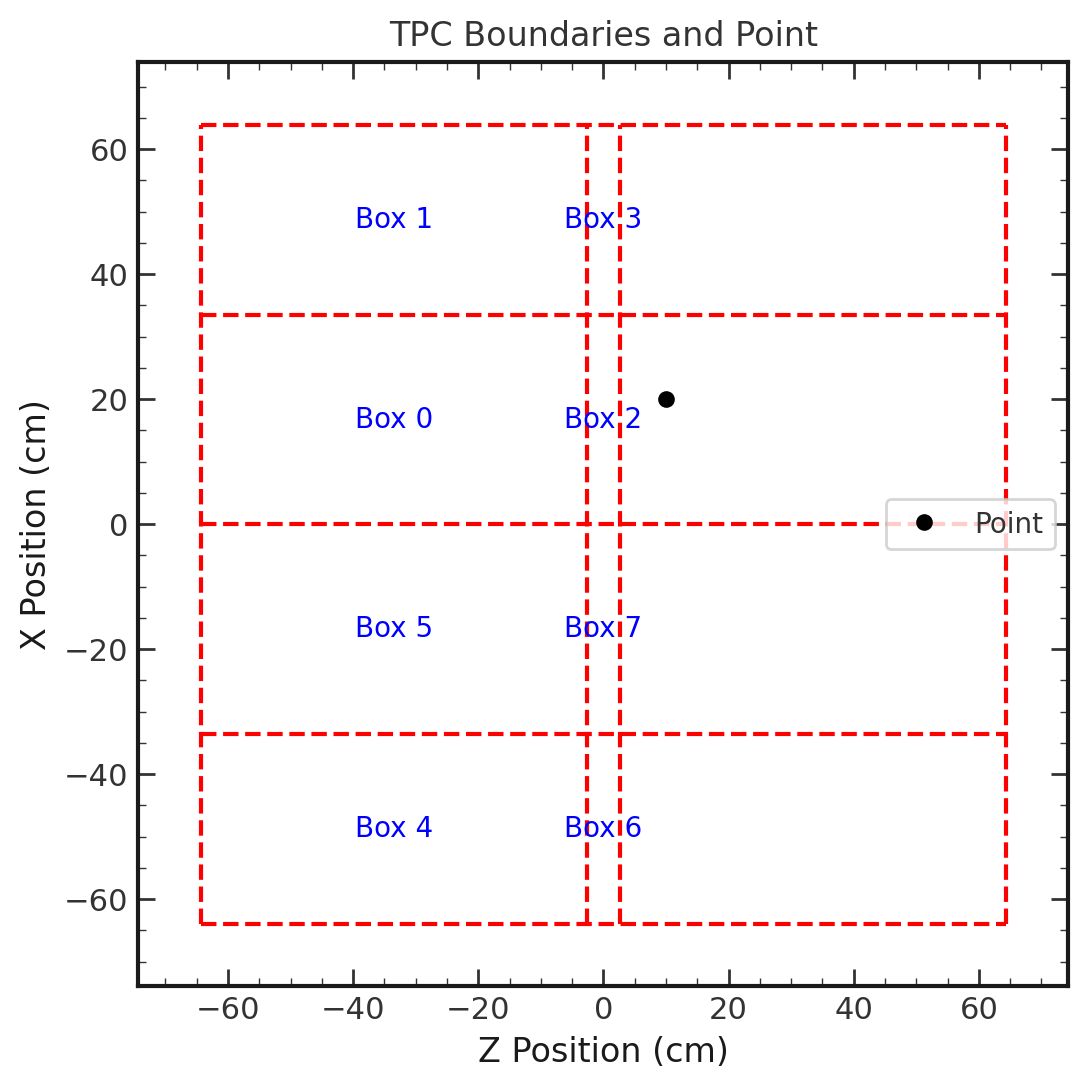

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the boundaries
z_boundaries = np.array([-64.3163, -2.6837, 2.6837, 64.3163])  # Z-axis (horizontal)
x_boundaries = np.array([-63.931, -33.5, 0, 33.5, 63.931])     # X-axis (vertical)

# Define the box mapping: (row, col) -> box ID
box_mapping = {
    (1, 1): 4, (2, 1): 5,   # Top-left (module 2)
    (1, 2): 6, (2, 2): 7,   # Top-right (module 3)
    (3, 1): 0, (4, 1): 1,   # Bottom-left (module 0)
    (3, 2): 2, (4, 2): 3    # Bottom-right (module 1)
}

def find_box(z, x, x_boundaries, box_mapping):
    # 1. Check for the gap first
    if -2.6837 < z < 2.6837:
        # This is the gap region; no box is assigned
        return None

    # 2. Determine which column we are in: left or right
    if -64.3163 <= z <= -2.6837:
        box_col = 1  # left side
    elif 2.6837 <= z <= 64.3163:
        box_col = 2  # right side
    else:
        return None

    # 3. Determine which row we are in by checking x boundaries
    box_row = None
    for j in range(len(x_boundaries) - 1):
        if x_boundaries[j] <= x <= x_boundaries[j + 1]:
            box_row = j + 1
            break

    if box_row is not None:
        # Debug output
        print(f"Point (z={z}, x={x}) => row={box_row}, col={box_col}")
        return box_mapping.get((box_row, box_col), None)
    else:
        return None

# # def plot_boundaries_and_point(z_boundaries, x_boundaries, point):
# #     fig, ax = plt.subplots(figsize=(6, 6))

# #     # Draw vertical lines for the left edge and right edge
# #     ax.plot([z_boundaries[0], z_boundaries[0]],
# #             [x_boundaries.min(), x_boundaries.max()], 'r--')
# #     ax.plot([z_boundaries[1], z_boundaries[1]],
# #             [x_boundaries.min(), x_boundaries.max()], 'r--')
# #     ax.plot([z_boundaries[2], z_boundaries[2]],
# #             [x_boundaries.min(), x_boundaries.max()], 'r--')
# #     ax.plot([z_boundaries[3], z_boundaries[3]],
# #             [x_boundaries.min(), x_boundaries.max()], 'r--')

# #     # Draw horizontal lines for x-boundaries
# #     for x in x_boundaries:
# #         ax.plot([z_boundaries.min(), z_boundaries.max()], [x, x], 'r--')

# #     # Add labels for boxes (only in left or right module)
# #     for row in range(1, len(x_boundaries)):
# #         for col in [1, 2]:  # Only two valid columns
# #             box = box_mapping.get((row, col), None)
# #             if box is not None:
# #                 # Find the center in z depending on col
# #                 if col == 1:
# #                     center_z = (z_boundaries[0] + z_boundaries[1]) / 2  # left side
# #                 else:
# #                     center_z = (z_boundaries[2] + z_boundaries[3]) / 2  # right side

# #                 # Center in x
# #                 center_x = (x_boundaries[row - 1] + x_boundaries[row]) / 2
# #                 ax.text(center_z, center_x, f"Box {box}", color="blue",
# #                         ha="center", va="center", fontsize=10)

# #     # Plot the point
# #     ax.plot(point[0], point[1], 'ko', label="Point")
# #     ax.legend()

# #     # Set axis limits and labels
# #     ax.set_xlim(z_boundaries.min() - 10, z_boundaries.max() + 10)
# #     ax.set_ylim(x_boundaries.min() - 10, x_boundaries.max() + 10)
# #     ax.set_xlabel("Z Position (cm)")
# #     ax.set_ylabel("X Position (cm)")
# #     ax.set_title("TPC Boundaries and Point")
# #     plt.grid()
# #     plt.show()

# # Example point
# point = (10, 20.0)  # (z, x) in the gap region
# box = find_box(point[0], point[1], x_boundaries, box_mapping)

# if box is not None:
#     print(f"Point {point} lies in box {box}.")
# else:
#     print(f"Point {point} is either outside the TPC or in the gap (no box).")

# # Plot the boundaries and the point
# plot_boundaries_and_point(z_boundaries, x_boundaries, point)


In [ ]:
plt.hist2d(track_vtx_distances,track_lengths,  bins=100, norm=mcolors.LogNorm(), cmap='viridis')
# plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 70)
plt.ylim(0, 30)
plt.colorbar(label='Counts')
plt.ylabel('Track length (cm)')
plt.xlabel('Distance from vertex (cm)')
#plt.yscale('log')
plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
plt.suptitle(r'True info', fontsize = '7')
#plt.legend(fontsize='8')
plt.show()

In [ ]:
#store num reco vtx for the cuts
num_neutrinos_dv_r=0 # in dv
num_neutrinos_fv_r=0 # in fv
num_neutrinos_muons = 0 #produced reco muon
num_neutrinos_muon_fv = 0 #produced reco muon in fv
num_neutrinos_prim_mu_fv=0 #produced prim muon in fv
#for tracks
num_track_fv = 0 # produced a track in fv
num_track_vtx_fv =0 #produced track that stat on vtx
num_track_vtx_out_fv=0 #produced track start on vtx and exit 2x2 downstream
num_track_Mx2_fv = 0 #num of tracks that crossed minerva 


reco_sec_proton=0
reco_primproton_with_bm_sec_proton  =0
reco_prim_proton =0
candidate_not_in_signal=0
candidate_in_signal =0 
count_sec =0

#store track length and distance to vtx 
track_lenghts_match_truth = [] #true particles best match 
vtx_distances_match_truth =[]  
track_lenghts_reco = []  #reco particles candidates
vtx_distances_reco =[]
E_bm_proton = []
E_reco_proton = []

#positions of the vtx that passed the reco signal cuts
vtx_x_signal=[]
vtx_y_signal=[]
vtx_z_signal=[]
#positions of the vtx the reco candidates
vtx_x_candidates=[]
vtx_y_candidates=[]
vtx_z_candidates=[]

candidate_event_vtx_r = []
candidate_event_vtx_t = []

vtx_x_bmcandidates=[]
vtx_y_bmcandidates=[]
vtx_z_bmcandidates=[]


bmnot_a_proton =[]
bmtrue_prim_proton=[]
bmtrue_intermediate_proton=[]

#stores values of what was reconstructed as sec proton but was something else
reco_proton_dic = {
    'best_match_idx': [] ,   
    'best_match_pdg': [],
    'best_match_type': [],
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],
    'parent_id' :[],
    'vtx_t': [],
    'vtx_r': [],
    'ev': [],
    'reco_inx': [],
    'max_overlap' :[]
}

sample_dic = {
    'best_match_length':[],
    'best_match_distance':[],
    'best_match_energy':[],
    'reco_distance':[],
    'reco_energy':[],
    'reco_length':[],

}

len_all=[]
dist_all =[]

len_alltrue=[]
dist_alltrue =[]

c=0
sec_protons=0
for ev in range(len(df)):
    


    ev_data= df.iloc[ev]

     #mask vertex on the fiducial volume
    mask_fv = (
        (abs(ev_data['rec.mc.nu.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.mc.nu.vtx.z'])<zbound-tpc_dist)
    )

    #mask vertex on the fiducial volume
    mask_fv_r = (
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])<xbound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.x'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.y'])<ybound-tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])>tpc_dist) &
        (abs(ev_data['rec.common.ixn.dlp.vtx.z'])<zbound-tpc_dist)
    )
    
    for vtx, value in enumerate(mask_fv_r):
        if value:
            n_ixn = len(ev_data['rec.common.ixn.dlp.id'])
            n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            if(vtx==0):
                n_pre = 0
            else: 
                n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) 


            # Scan over particles associated to this ixn 
            for ip in range(n_pre,n_pre + n_particles):
                reco_pdg = ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
                if(reco_pdg==pdg_tab.proton):
                    #require the end of the track in the detector 
                    #end track proton
                    vx_e= ev_data['rec.common.ixn.dlp.part.dlp.end.x'][ip]
                    vy_e= ev_data['rec.common.ixn.dlp.part.dlp.end.y'][ip]
                    vz_e= ev_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
                    #start track proton
                    vx_s= ev_data['rec.common.ixn.dlp.part.dlp.start.x'][ip]
                    vy_s= ev_data['rec.common.ixn.dlp.part.dlp.start.y'][ip]
                    vz_s= ev_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]              
                    iscontained = isContainedFV(vx_e,vy_e,vz_e) 
                    
                    if iscontained:             
                        #vtx position
                        vx= ev_data['rec.common.ixn.dlp.vtx.x'][vtx]
                        vy= ev_data['rec.common.ixn.dlp.vtx.y'][vtx]
                        vz= ev_data['rec.common.ixn.dlp.vtx.z'][vtx]
                        track_length, vtx_distance = calculate_track_properties((vx_s,vy_s,vz_s), (vx_e,vy_e,vz_e), (vx,vy,vz))
                        len_all.append(track_length)
                        dist_all.append(vtx_distance)
                    



    for vtx, value in enumerate(mask_fv):
        if value == True:
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx] #num of total prim
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]   #num of total sec

            #Luis's trick to iterate between primaries/sec per vtx
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])

            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.proton):
                    iscontained_p = isContainedFV(ev_data['rec.mc.nu.prim.end_pos.x'][ip], ev_data['rec.mc.nu.prim.end_pos.y'][ip], ev_data['rec.mc.nu.prim.end_pos.z'][ip], 2)
                    if iscontained_p:
                        track_length, vtx_distance = calculate_track_properties(
                            (ev_data['rec.mc.nu.prim.start_pos.x'][ip], ev_data['rec.mc.nu.prim.start_pos.y'][ip], ev_data['rec.mc.nu.prim.start_pos.z'][ip]),
                            (ev_data['rec.mc.nu.prim.end_pos.x'][ip], ev_data['rec.mc.nu.prim.end_pos.y'][ip], ev_data['rec.mc.nu.prim.end_pos.z'][ip]),
                            (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                        )
                        len_alltrue.append(track_length)
                        dist_alltrue.append(vtx_distance)

            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                if (ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton):
                    iscontained_p = isContainedFV(ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec], 2)
                    if iscontained_p:
                        track_length, vtx_distance = calculate_track_properties(
                            (ev_data['rec.mc.nu.sec.start_pos.x'][isec], ev_data['rec.mc.nu.sec.start_pos.y'][isec], ev_data['rec.mc.nu.sec.start_pos.z'][isec]),
                            (ev_data['rec.mc.nu.sec.end_pos.x'][isec], ev_data['rec.mc.nu.sec.end_pos.y'][isec], ev_data['rec.mc.nu.sec.end_pos.z'][isec]),
                            (ev_data['rec.mc.nu.vtx.x'][vtx], ev_data['rec.mc.nu.vtx.y'][vtx], ev_data['rec.mc.nu.vtx.z'][vtx])
                        )
                        len_alltrue.append(track_length)
                        dist_alltrue.append(vtx_distance)
